In [1]:
import warnings

import ast
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import classification_report, mean_absolute_error, r2_score

import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

In [2]:
cyr = ['а','б','в','г','д','е','ё','ж','з','и','й','к','л','м','н','о','п','р','с','т','у','ф','х','ц','ч','ш','щ','ъ','ы','ь','э','ю','я','ґ','є','ї','ђ','љ','њ','ћ','џ', 'ў','ъ']
lat = ['a','b','v','g','d','e','jo','zh','z','i','j','k','l','m','n','o','p','r','s','t','u','f','h','ts','ch','sh','sczs','','y','','e','ju','ja','g','e','j','dzh','l','n','ch','dzh', 'w','o']
lat2 = ['ch','cz','rz','sz', 'a','b','c','d','e','f','g','h','i','j','k','l','m','n','o','p','qu','r','s','t','u','v','w','x', 'y','z','ą', 'ć','ę', 'ł','ń','ó','ś','ź','ż','á','č','ď','é','ě','í','ň','ř', 'š','ť','ú','ů','ý','ž','ä','ľ','ĺ', 'ô', 'ŕ','è']
cyr2 = ['х', 'ч', 'ж', 'ш',  'а','б','ц','д','е','ф','г','х','и','й','к','л','м','н','о','п','кв','р','с','т','у','в','в','кс','ы','з','ом','ч','ен','л','н','у','ш','ж','ж','а','ч','д','э','е','и','н','рж','ш','т','у','у','и','ж','э','л','лл','уо','рр','э']
langss = ['-', 'c', 'c', 'c', 'l', 'l', 'l', 'c', 'l']

# Transliterates text into proper script: 'c' - Cyrillic into Latinic, 'l' - conversely.
def transliterate(sss, l_kind):
  try:
    sss2 = sss.lower()

    if l_kind == 'c':
        l_from, l_to = cyr, lat
    elif l_kind == 'l':
        l_from, l_to = lat2, cyr2
    else:
        return ""
    for c, l in zip(l_from, l_to):
        try:
            sss2 = sss2.replace(c, l)
        except:
            pass
  except:
    pass
  return sss2

In [4]:
df_all_n = pd.DataFrame()  # "настоящие" когнаты по всем языкам 
df_all1_n = pd.DataFrame()  # "частичные" когнаты (когнаты синонимов правильных ответов) по всем языкам
df_all2_n = pd.DataFrame()  # "настоящие" + "частичные" когнаты по всем языкам
df_both_n = pd.DataFrame()  # для одного языка
columns = [
    'pair', 'ukr', 'bel', 'bg', 'sb', 'pol', 'cz', 'sk', 'sn', 'postfix_position', 'different_agreement',
    'PREF1', 'PREF2', 'ROOT1', 'ROOT2', 'LINK', 'SUFF1', 'SUFF2', 'SUFF3',
    'END', 'POSTFIX', 'explained_mistakes'
]
df_all_langs_n = pd.DataFrame(columns=columns)  # "настоящие" когнаты по всем языкам + информация, к какому языку относится когнат
df_all_langs1_n = pd.DataFrame(columns=columns)  # "частичные" когнаты по всем языкам + информация, к какому языку относится когнат
df_all_langs2_n = pd.DataFrame(columns=columns)  # "настоящие" + "частичные" когнаты по всем языкам + информация, к какому языку относится когнат

In [5]:
# Функция для добавления информации о языке когната:

def add_rows(source_df, target_df, column_to_fill):
    new_columns = ['ukr', 'bel', 'bg', 'sb', 'pol', 'cz', 'sk', 'sn']
    rows_to_add = source_df.copy()
    for col in new_columns:
        rows_to_add[col] = 0.0
    if column_to_fill and column_to_fill in new_columns:
        rows_to_add[column_to_fill] = 1.0
    rows_to_add = rows_to_add[target_df.columns]
    target_df = pd.concat([target_df, rows_to_add], ignore_index=True)
    return target_df

In [6]:
def normalize_levenshtein_in_dataframe(df, translit=False,
                                       distance_columns=['PREF1', 'PREF2', 'ROOT1', 'ROOT2', 'LINK', 'SUFF1', 'SUFF2', 'SUFF3', 'END', 'POSTFIX'],
                                       clean_soft_sign=True):
    df = df.copy()
    
    def clean_word(word):
        return str(word).replace('ь', '')
    
    def get_max_length(pair_string):
        words = ast.literal_eval(pair_string)[1:]
        word1, word2 = words[0], words[1]
        if clean_soft_sign:
            word1 = clean_word(word1)
            word2 = clean_word(word2)
        return max(len(word1), len(word2))
    
    word_lengths = df['pair'].apply(get_max_length)
    
    for col in distance_columns:
        df[col] = df.apply(lambda row: row[col] / word_lengths[row.name], axis=1)
    
    return df

In [7]:
def check_row(row):
    if (row['pred_class'] == 0 and row['explained_mistakes'] >= 0) or (row['pred_class'] == 1 and row['explained_mistakes'] < 0):
        return 'correct'
    else:
        return 'incorrect'

In [8]:
count_n = 0

In [9]:
def regression_results(file, language, f_type='b', normalize=True):
    
    if isinstance(file, str):
        df = pd.read_csv(file)
    else:
        df = file.copy()
     
    if normalize and f_type != 'b':
        if language in ['ukr', 'bel', 'bg', 'sb']:
            df = normalize_levenshtein_in_dataframe(df)
        else:
            df = normalize_levenshtein_in_dataframe(df, True)
            
    global df_both_n, count_n
    if normalize:   
        if count_n < 2:
            df_both_n = pd.concat([df_both_n, df], ignore_index=True)
            count_n += 1
        elif count_n == 2:
            df_both_n = pd.DataFrame()
            count_n = 0
    
    if normalize:
        global df_all_n, df_all1_n, df_all2_n, df_all_langs_n, df_all_langs1_n, df_all_langs2_n
        if f_type == 't':
            df_all_n = pd.concat([df_all_n, df], ignore_index=True)
            df_all_langs_n = add_rows(df, df_all_langs_n, column_to_fill=language)
        elif f_type == 'p':
            df_all1_n = pd.concat([df_all1_n, df], ignore_index=True)
            df_all_langs1_n = add_rows(df, df_all_langs1_n, column_to_fill=language)
        else:
            df_all2_n = pd.concat([df_all2_n, df], ignore_index=True)
            df_all_langs2_n = add_rows(df, df_all_langs2_n, column_to_fill=language)
    
    if 'pair' in df.columns:
        df1 = df.drop('pair', axis=1)
    
    # предсказываем, ухудшилось ли угадывание при наличии параллельного тектста (1), или улучшилось / осталось прежним (0) 
    df1['binary'] = (df1['explained_mistakes'] < 0).astype(int)
    
    x = df1.loc[:, :'POSTFIX']
    y = df1['binary']
    
    x_train, x_test, y_train, y_test = train_test_split(
        x, y, test_size=0.2, stratify=y, random_state=42
    )    
    
    train_indices = x_train.index
    test_indices = x_test.index

    X_train_np = x_train.to_numpy()
    y_train_np = y_train.to_numpy()
    X_test_np = x_test.to_numpy()
    y_test_np = y_test.to_numpy()

    scaler = StandardScaler()
    x_train_np = scaler.fit_transform(X_train_np)
    x_test_np = scaler.transform(X_test_np)
    
    reg = LogisticRegression(max_iter=1000)
    
    cv_results = cross_validate(reg, x_train_np, y_train_np, cv=5, scoring='f1_macro')
    cv_output = pd.DataFrame(cv_results).sort_values(['test_score'], ascending=False)

    reg.fit(x_train_np, y_train_np)
    
    y_pred = reg.predict(x_test_np)
    y_pred_proba = reg.predict_proba(x_test_np)[:, 1]
    
    df.loc[test_indices, 'pred_class'] = y_pred
    df.loc[test_indices, 'pred_proba'] = y_pred_proba

    dff = df.copy()
    dff = dff.drop(test_indices)
    
    df = df.drop(train_indices)
    df['correctness'] = df.apply(check_row, axis=1)
    
    return cv_output, classification_report(y_test_np, y_pred), df, reg.coef_[0], dff

## Украинский

### True norm

In [14]:
results = regression_results('for_regression/true/ukr_true.csv', 'ukr', 't', True)
df = results[2]
dff = results[4]
coef = results[3]
results[0]

,fit_time,score_time,test_score
1,0.002274,0.003494,0.641577
3,0.002809,0.002494,0.600000
4,0.002274,0.002449,0.567100
0,0.002770,0.002445,0.411765
2,0.002680,0.002285,0.393939


In [15]:
print(results[1])

              precision    recall  f1-score   support

           0       0.76      1.00      0.86        19
           1       1.00      0.14      0.25         7

    accuracy                           0.77        26
   macro avg       0.88      0.57      0.56        26
weighted avg       0.82      0.77      0.70        26



In [16]:
df.to_csv(
    'logreg_ana/true_norm/ukr_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

In [17]:
for col, coef in zip(df.columns[1:-3], coef):
    print(f'{col}: {round(coef, 3)}')

postfix_position: 0.0
different_agreement: 0.0
PREF1: 0.347
PREF2: 0.0
ROOT1: 0.35
ROOT2: 0.219
LINK: 0.219
SUFF1: 0.216
SUFF2: 0.193
SUFF3: -0.429
END: 0.285
POSTFIX: 0.221


In [18]:
import umap
import plotly.express as px

morpheme_cols = ['postfix_position', 'different_agreement', 'PREF1', 'PREF2', 'ROOT1', 'ROOT2', 'LINK', 
                 'SUFF1', 'SUFF2', 'SUFF3', 'END', 'POSTFIX']

df_concat = pd.concat([df, dff], ignore_index=True)
X = df_concat[morpheme_cols].copy()

# UMAP до 2D
reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(X)

# Добавляем координаты и класс
df_viz = df_concat.copy()
df_viz['x_umap'] = embedding[:, 0]
df_viz['y_umap'] = embedding[:, 1]
df_viz['Класс'] = (df_concat['explained_mistakes'] < 0).map({True: 'Ухудшение', False: 'Нет ухудшения'})

# Интерактивный график
fig = px.scatter(df_viz, 
                 x='x_umap',        
                 y='y_umap',        
                 color='Класс',
                 color_discrete_map={'Нет ухудшения': '#6A5ACD', 'Ухудшение': '#F08080'},
                 hover_data=['pair', 'PREF1', 'ROOT1', 'SUFF1'],
                 title='Разделение классов по морфемным расстояниям')

fig.update_layout(
    plot_bgcolor='lavender',
    paper_bgcolor='white'
)
fig.show()

### Part norm

In [23]:
results = regression_results('for_regression/part/ukr_part1.csv', 'ukr', 'p', True)
df = results[2]
dff = results[4]
coef = results[3]
results[0]

,fit_time,score_time,test_score
0,0.001999,0.002437,0.777778
2,0.001888,0.002028,0.666667
3,0.001917,0.002302,0.583333
4,0.002633,0.002468,0.583333
1,0.002138,0.002040,0.333333


In [24]:
print(results[1])

              precision    recall  f1-score   support

           0       0.57      1.00      0.73         4
           1       0.00      0.00      0.00         3

    accuracy                           0.57         7
   macro avg       0.29      0.50      0.36         7
weighted avg       0.33      0.57      0.42         7



In [25]:
df.to_csv(
    'logreg_ana/part_norm/ukr_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

In [26]:
for col, coef in zip(df.columns[1:-3], coef):
    print(f'{col}: {round(coef, 3)}')

postfix_position: 0.0
different_agreement: -0.296
PREF1: 1.097
PREF2: 0.43
ROOT1: 0.16
ROOT2: 0.0
LINK: 0.483
SUFF1: 0.273
SUFF2: -0.248
SUFF3: 0.0
END: 0.261
POSTFIX: -0.396


In [27]:
morpheme_cols = ['postfix_position', 'different_agreement', 'PREF1', 'PREF2', 'ROOT1', 'ROOT2', 'LINK', 
                 'SUFF1', 'SUFF2', 'SUFF3', 'END', 'POSTFIX']

df_concat = pd.concat([df, dff], ignore_index=True)
X = df_concat[morpheme_cols].copy()

# UMAP до 2D
reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(X)

# Добавляем координаты и класс
df_viz = df_concat.copy()
df_viz['x_umap'] = embedding[:, 0]
df_viz['y_umap'] = embedding[:, 1]
df_viz['Класс'] = (df_concat['explained_mistakes'] < 0).map({True: 'Ухудшение', False: 'Нет ухудшения'})

# Интерактивный график
fig = px.scatter(df_viz, 
                 x='x_umap',        
                 y='y_umap',        
                 color='Класс',
                 color_discrete_map={'Нет ухудшения': '#6A5ACD', 'Ухудшение': '#F08080'},
                 hover_data=['pair', 'PREF1', 'ROOT1', 'SUFF1'],
                 title='Разделение классов по морфемным расстояниям')

fig.update_layout(
    plot_bgcolor='lavender',
    paper_bgcolor='white'
)
fig.show()

### Both norm

In [32]:
results = regression_results(df_both_n, 'ukr', 'b', True)
df = results[2]
dff = results[4]
coef = results[3]
results[0]

,fit_time,score_time,test_score
4,0.001564,0.001991,0.740125
1,0.002292,0.002426,0.641026
2,0.003285,0.003146,0.609023
0,0.003520,0.002587,0.596452
3,0.003677,0.003304,0.525745


In [33]:
print(results[1])

              precision    recall  f1-score   support

           0       0.71      0.96      0.81        23
           1       0.50      0.10      0.17        10

    accuracy                           0.70        33
   macro avg       0.60      0.53      0.49        33
weighted avg       0.65      0.70      0.62        33



In [34]:
df.to_csv(
    'logreg_ana/both_norm/ukr_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

In [35]:
for col, coef in zip(df.columns[1:-3], coef):
    print(f'{col}: {round(coef, 3)}')

postfix_position: 0.0
different_agreement: 0.0
PREF1: 0.792
PREF2: 0.366
ROOT1: 0.305
ROOT2: 0.14
LINK: 0.509
SUFF1: 0.123
SUFF2: -0.039
SUFF3: -0.342
END: 0.18
POSTFIX: 0.057


In [36]:
morpheme_cols = ['postfix_position', 'different_agreement', 'PREF1', 'PREF2', 'ROOT1', 'ROOT2', 'LINK', 
                 'SUFF1', 'SUFF2', 'SUFF3', 'END', 'POSTFIX']

df_concat = pd.concat([df, dff], ignore_index=True)
X = df_concat[morpheme_cols].copy()

# UMAP до 2D
reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(X)

# Добавляем координаты и класс
df_viz = df_concat.copy()
df_viz['x_umap'] = embedding[:, 0]
df_viz['y_umap'] = embedding[:, 1]
df_viz['Класс'] = (df_concat['explained_mistakes'] < 0).map({True: 'Ухудшение', False: 'Нет ухудшения'})

# Интерактивный график
fig = px.scatter(df_viz, 
                 x='x_umap',        
                 y='y_umap',        
                 color='Класс',
                 color_discrete_map={'Нет ухудшения': '#6A5ACD', 'Ухудшение': '#F08080'},
                 hover_data=['pair', 'PREF1', 'ROOT1', 'SUFF1'],
                 title='Разделение классов по морфемным расстояниям')

fig.update_layout(
    plot_bgcolor='lavender',
    paper_bgcolor='white'
)
fig.show()

## Белорусский

### True norm

In [41]:
results = regression_results('for_regression/true/bel_true.csv', 'bel', 't', True)
df = results[2]
dff = results[4]
coef = results[3]
results[0]

,fit_time,score_time,test_score
4,0.001531,0.001520,0.715100
3,0.001359,0.001589,0.642857
0,0.003251,0.003277,0.610080
1,0.002947,0.002611,0.571429
2,0.001842,0.001732,0.487179


In [42]:
print(results[1])

              precision    recall  f1-score   support

           0       0.67      0.75      0.71        16
           1       0.50      0.40      0.44        10

    accuracy                           0.62        26
   macro avg       0.58      0.57      0.58        26
weighted avg       0.60      0.62      0.61        26



In [43]:
df.to_csv(
    'logreg_ana/true_norm/bel_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

In [44]:
for col, coef in zip(df.columns[1:-3], coef):
    print(f'{col}: {round(coef, 3)}')

postfix_position: 0.0
different_agreement: 0.0
PREF1: 0.27
PREF2: -0.353
ROOT1: 0.307
ROOT2: 0.0
LINK: -0.246
SUFF1: 0.338
SUFF2: 0.28
SUFF3: -0.491
END: 0.204
POSTFIX: 0.576


In [45]:
morpheme_cols = ['postfix_position', 'different_agreement', 'PREF1', 'PREF2', 'ROOT1', 'ROOT2', 'LINK', 
                 'SUFF1', 'SUFF2', 'SUFF3', 'END', 'POSTFIX']

df_concat = pd.concat([df, dff], ignore_index=True)
X = df_concat[morpheme_cols].copy()

# UMAP до 2D
reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(X)

# Добавляем координаты и класс
df_viz = df_concat.copy()
df_viz['x_umap'] = embedding[:, 0]
df_viz['y_umap'] = embedding[:, 1]
df_viz['Класс'] = (df_concat['explained_mistakes'] < 0).map({True: 'Ухудшение', False: 'Нет ухудшения'})

# Интерактивный график
fig = px.scatter(df_viz, 
                 x='x_umap',        
                 y='y_umap',        
                 color='Класс',
                 color_discrete_map={'Нет ухудшения': '#6A5ACD', 'Ухудшение': '#F08080'},
                 hover_data=['pair', 'PREF1', 'ROOT1', 'SUFF1'],
                 title='Разделение классов по морфемным расстояниям')

fig.update_layout(
    plot_bgcolor='lavender',
    paper_bgcolor='white'
)
fig.show()

### Part norm

In [50]:
results = regression_results('for_regression/part/bel_part1.csv', 'bel', 'p', True)
df = results[2]
dff = results[4]
coef = results[3]
results[0]

,fit_time,score_time,test_score
1,0.001032,0.001216,0.857143
4,0.001042,0.001686,0.708333
3,0.000961,0.001175,0.708333
0,0.003178,0.001717,0.571429
2,0.000915,0.001706,0.533333


In [51]:
print(results[1])

              precision    recall  f1-score   support

           0       0.60      0.60      0.60         5
           1       0.50      0.50      0.50         4

    accuracy                           0.56         9
   macro avg       0.55      0.55      0.55         9
weighted avg       0.56      0.56      0.56         9



In [52]:
df.to_csv(
    'logreg_ana/part_norm/bel_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

In [53]:
for col, coef in zip(df.columns[1:-3], coef):
    print(f'{col}: {round(coef, 3)}')

postfix_position: 0.0
different_agreement: 0.157
PREF1: 0.362
PREF2: 0.835
ROOT1: 0.18
ROOT2: 0.0
LINK: 0.0
SUFF1: 1.123
SUFF2: 0.216
SUFF3: 0.0
END: -0.005
POSTFIX: -0.309


In [54]:
morpheme_cols = ['postfix_position', 'different_agreement', 'PREF1', 'PREF2', 'ROOT1', 'ROOT2', 'LINK', 
                 'SUFF1', 'SUFF2', 'SUFF3', 'END', 'POSTFIX']

df_concat = pd.concat([df, dff], ignore_index=True)
X = df_concat[morpheme_cols].copy()

# UMAP до 2D
reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(X)

# Добавляем координаты и класс
df_viz = df_concat.copy()
df_viz['x_umap'] = embedding[:, 0]
df_viz['y_umap'] = embedding[:, 1]
df_viz['Класс'] = (df_concat['explained_mistakes'] < 0).map({True: 'Ухудшение', False: 'Нет ухудшения'})

# Интерактивный график
fig = px.scatter(df_viz, 
                 x='x_umap',        
                 y='y_umap',        
                 color='Класс',
                 color_discrete_map={'Нет ухудшения': '#6A5ACD', 'Ухудшение': '#F08080'},
                 hover_data=['pair', 'PREF1', 'ROOT1', 'SUFF1'],
                 title='Разделение классов по морфемным расстояниям')

fig.update_layout(
    plot_bgcolor='lavender',
    paper_bgcolor='white'
)
fig.show()

### Both norm

In [59]:
results = regression_results(df_both_n, 'bel', 'b', True)
df = results[2]
dff = results[4]
coef = results[3]
results[0]

,fit_time,score_time,test_score
1,0.001494,0.002675,0.700535
0,0.002609,0.001915,0.657143
2,0.002280,0.001939,0.583333
4,0.001968,0.001604,0.553383
3,0.001832,0.001730,0.441971


In [60]:
print(results[1])

              precision    recall  f1-score   support

           0       0.70      0.76      0.73        21
           1       0.58      0.50      0.54        14

    accuracy                           0.66        35
   macro avg       0.64      0.63      0.63        35
weighted avg       0.65      0.66      0.65        35



In [61]:
df.to_csv(
    'logreg_ana/both_norm/bel_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

In [62]:
for col, coef in zip(df.columns[1:-3], coef):
    print(f'{col}: {round(coef, 3)}')

postfix_position: 0.0
different_agreement: 0.112
PREF1: 0.411
PREF2: 0.538
ROOT1: 0.165
ROOT2: 0.0
LINK: 0.17
SUFF1: 0.508
SUFF2: 0.202
SUFF3: -0.485
END: -0.078
POSTFIX: 0.147


In [63]:
morpheme_cols = ['postfix_position', 'different_agreement', 'PREF1', 'PREF2', 'ROOT1', 'ROOT2', 'LINK', 
                 'SUFF1', 'SUFF2', 'SUFF3', 'END', 'POSTFIX']

df_concat = pd.concat([df, dff], ignore_index=True)
X = df_concat[morpheme_cols].copy()

# UMAP до 2D
reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(X)

# Добавляем координаты и класс
df_viz = df_concat.copy()
df_viz['x_umap'] = embedding[:, 0]
df_viz['y_umap'] = embedding[:, 1]
df_viz['Класс'] = (df_concat['explained_mistakes'] < 0).map({True: 'Ухудшение', False: 'Нет ухудшения'})

# Интерактивный график
fig = px.scatter(df_viz, 
                 x='x_umap',        
                 y='y_umap',        
                 color='Класс',
                 color_discrete_map={'Нет ухудшения': '#6A5ACD', 'Ухудшение': '#F08080'},
                 hover_data=['pair', 'PREF1', 'ROOT1', 'SUFF1'],
                 title='Разделение классов по морфемным расстояниям')

fig.update_layout(
    plot_bgcolor='lavender',
    paper_bgcolor='white'
)
fig.show()

## Болгарский

### True norm

In [68]:
results = regression_results('for_regression/true/bg_true.csv', 'bg', 't', True)
df = results[2]
dff = results[4]
coef = results[3]
results[0]

,fit_time,score_time,test_score
2,0.005722,0.003049,0.634615
0,0.002609,0.004256,0.590769
1,0.004156,0.003416,0.552189
4,0.002222,0.001862,0.481481
3,0.002743,0.002253,0.457143


In [69]:
print(results[1])

              precision    recall  f1-score   support

           0       0.60      0.64      0.62        14
           1       0.44      0.40      0.42        10

    accuracy                           0.54        24
   macro avg       0.52      0.52      0.52        24
weighted avg       0.54      0.54      0.54        24



In [70]:
df.to_csv(
    'logreg_ana/true_norm/bg_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

In [71]:
for col, coef in zip(df.columns[1:-3], coef):
    print(f'{col}: {round(coef, 3)}')

postfix_position: -0.052
different_agreement: 0.0
PREF1: 0.421
PREF2: 0.0
ROOT1: 0.196
ROOT2: -0.277
LINK: 0.0
SUFF1: 0.082
SUFF2: -0.12
SUFF3: -0.532
END: 0.323
POSTFIX: 0.059


In [72]:
morpheme_cols = ['postfix_position', 'different_agreement', 'PREF1', 'PREF2', 'ROOT1', 'ROOT2', 'LINK', 
                 'SUFF1', 'SUFF2', 'SUFF3', 'END', 'POSTFIX']

df_concat = pd.concat([df, dff], ignore_index=True)
X = df_concat[morpheme_cols].copy()

# UMAP до 2D
reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(X)

# Добавляем координаты и класс
df_viz = df_concat.copy()
df_viz['x_umap'] = embedding[:, 0]
df_viz['y_umap'] = embedding[:, 1]
df_viz['Класс'] = (df_concat['explained_mistakes'] < 0).map({True: 'Ухудшение', False: 'Нет ухудшения'})

# Интерактивный график
fig = px.scatter(df_viz, 
                 x='x_umap',        
                 y='y_umap',        
                 color='Класс',
                 color_discrete_map={'Нет ухудшения': '#6A5ACD', 'Ухудшение': '#F08080'},
                 hover_data=['pair', 'PREF1', 'ROOT1', 'SUFF1'],
                 title='Разделение классов по морфемным расстояниям')

fig.update_layout(
    plot_bgcolor='lavender',
    paper_bgcolor='white'
)
fig.show()

### Part norm

In [77]:
results = regression_results('for_regression/part/bg_part1.csv', 'bg', 'p', True)
df = results[2]
dff = results[4]
coef = results[3]
results[0]

,fit_time,score_time,test_score
1,0.002435,0.003153,1.000000
0,0.002754,0.002556,0.708333
4,0.001882,0.002328,0.485714
3,0.002238,0.002306,0.333333
2,0.002161,0.002383,0.300000


In [78]:
print(results[1])

              precision    recall  f1-score   support

           0       0.50      0.40      0.44         5
           1       0.40      0.50      0.44         4

    accuracy                           0.44         9
   macro avg       0.45      0.45      0.44         9
weighted avg       0.46      0.44      0.44         9



In [79]:
df.to_csv(
    'logreg_ana/part_norm/bg_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

In [80]:
for col, coef in zip(df.columns[1:-3], coef):
    print(f'{col}: {round(coef, 3)}')

postfix_position: 0.0
different_agreement: -0.703
PREF1: 0.468
PREF2: 0.337
ROOT1: -0.497
ROOT2: 0.0
LINK: 0.0
SUFF1: 0.497
SUFF2: 0.279
SUFF3: 0.673
END: -0.484
POSTFIX: -0.342


In [81]:
morpheme_cols = ['postfix_position', 'different_agreement', 'PREF1', 'PREF2', 'ROOT1', 'ROOT2', 'LINK', 
                 'SUFF1', 'SUFF2', 'SUFF3', 'END', 'POSTFIX']

df_concat = pd.concat([df, dff], ignore_index=True)
X = df_concat[morpheme_cols].copy()

# UMAP до 2D
reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(X)

# Добавляем координаты и класс
df_viz = df_concat.copy()
df_viz['x_umap'] = embedding[:, 0]
df_viz['y_umap'] = embedding[:, 1]
df_viz['Класс'] = (df_concat['explained_mistakes'] < 0).map({True: 'Ухудшение', False: 'Нет ухудшения'})

# Интерактивный график
fig = px.scatter(df_viz, 
                 x='x_umap',        
                 y='y_umap',        
                 color='Класс',
                 color_discrete_map={'Нет ухудшения': '#6A5ACD', 'Ухудшение': '#F08080'},
                 hover_data=['pair', 'PREF1', 'ROOT1', 'SUFF1'],
                 title='Разделение классов по морфемным расстояниям')

fig.update_layout(
    plot_bgcolor='lavender',
    paper_bgcolor='white'
)
fig.show()

### Both norm

In [86]:
results = regression_results(df_both_n, 'bg', 'b', True)
df = results[2]
dff = results[4]
coef = results[3]
results[0]

,fit_time,score_time,test_score
3,0.003903,0.004075,0.826389
4,0.004617,0.002863,0.598930
1,0.001812,0.001862,0.578378
2,0.001957,0.003315,0.543860
0,0.001485,0.001404,0.512500


In [87]:
print(results[1])

              precision    recall  f1-score   support

           0       0.67      0.89      0.76        18
           1       0.75      0.43      0.55        14

    accuracy                           0.69        32
   macro avg       0.71      0.66      0.65        32
weighted avg       0.70      0.69      0.67        32



In [88]:
df.to_csv(
    'logreg_ana/both_norm/bg_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

In [89]:
for col, coef in zip(df.columns[1:-3], coef):
    print(f'{col}: {round(coef, 3)}')

postfix_position: -0.611
different_agreement: -0.102
PREF1: 0.412
PREF2: 0.237
ROOT1: 0.135
ROOT2: -0.26
LINK: 0.0
SUFF1: 0.201
SUFF2: 0.332
SUFF3: -0.148
END: 0.151
POSTFIX: 0.46


In [90]:
morpheme_cols = ['postfix_position', 'different_agreement', 'PREF1', 'PREF2', 'ROOT1', 'ROOT2', 'LINK', 
                 'SUFF1', 'SUFF2', 'SUFF3', 'END', 'POSTFIX']

df_concat = pd.concat([df, dff], ignore_index=True)
X = df_concat[morpheme_cols].copy()

# UMAP до 2D
reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(X)

# Добавляем координаты и класс
df_viz = df_concat.copy()
df_viz['x_umap'] = embedding[:, 0]
df_viz['y_umap'] = embedding[:, 1]
df_viz['Класс'] = (df_concat['explained_mistakes'] < 0).map({True: 'Ухудшение', False: 'Нет ухудшения'})

# Интерактивный график
fig = px.scatter(df_viz, 
                 x='x_umap',        
                 y='y_umap',        
                 color='Класс',
                 color_discrete_map={'Нет ухудшения': '#6A5ACD', 'Ухудшение': '#F08080'},
                 hover_data=['pair', 'PREF1', 'ROOT1', 'SUFF1'],
                 title='Разделение классов по морфемным расстояниям')

fig.update_layout(
    plot_bgcolor='lavender',
    paper_bgcolor='white'
)
fig.show()

## Сербский

### True norm

In [95]:
results = regression_results('for_regression/true/sb_true.csv', 'sb', 't', True)
df = results[2]
dff = results[4]
coef = results[3]
results[0]

,fit_time,score_time,test_score
0,0.002591,0.002204,0.733333
3,0.001261,0.001423,0.653680
1,0.002290,0.002197,0.600000
2,0.001244,0.001487,0.515152
4,0.001283,0.001435,0.464286


In [96]:
print(results[1])

              precision    recall  f1-score   support

           0       0.64      0.82      0.72        11
           1       0.67      0.44      0.53         9

    accuracy                           0.65        20
   macro avg       0.65      0.63      0.63        20
weighted avg       0.65      0.65      0.64        20



In [97]:
df.to_csv(
    'logreg_ana/true_norm/sb_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

In [98]:
for col, coef in zip(df.columns[1:-3], coef):
    print(f'{col}: {round(coef, 3)}')

postfix_position: 0.0
different_agreement: 0.0
PREF1: 0.969
PREF2: 0.468
ROOT1: 0.07
ROOT2: 0.226
LINK: 0.226
SUFF1: 0.377
SUFF2: 0.533
SUFF3: 0.179
END: 0.034
POSTFIX: -0.47


In [99]:
morpheme_cols = ['postfix_position', 'different_agreement', 'PREF1', 'PREF2', 'ROOT1', 'ROOT2', 'LINK', 
                 'SUFF1', 'SUFF2', 'SUFF3', 'END', 'POSTFIX']

df_concat = pd.concat([df, dff], ignore_index=True)
X = df_concat[morpheme_cols].copy()

# UMAP до 2D
reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(X)

# Добавляем координаты и класс
df_viz = df_concat.copy()
df_viz['x_umap'] = embedding[:, 0]
df_viz['y_umap'] = embedding[:, 1]
df_viz['Класс'] = (df_concat['explained_mistakes'] < 0).map({True: 'Ухудшение', False: 'Нет ухудшения'})

# Интерактивный график
fig = px.scatter(df_viz, 
                 x='x_umap',        
                 y='y_umap',        
                 color='Класс',
                 color_discrete_map={'Нет ухудшения': '#6A5ACD', 'Ухудшение': '#F08080'},
                 hover_data=['pair', 'PREF1', 'ROOT1', 'SUFF1'],
                 title='Разделение классов по морфемным расстояниям')

fig.update_layout(
    plot_bgcolor='lavender',
    paper_bgcolor='white'
)
fig.show()

### Part norm

In [104]:
results = regression_results('for_regression/part/sb_part1.csv', 'sb', 'p', True)
df = results[2]
dff = results[4]
coef = results[3]
results[0]

,fit_time,score_time,test_score
0,0.003221,0.002955,0.466667
1,0.003576,0.002579,0.365079
2,0.002330,0.002123,0.365079
4,0.001875,0.001939,0.333333
3,0.002052,0.002045,0.272727


In [105]:
print(results[1])

              precision    recall  f1-score   support

           0       0.56      0.83      0.67         6
           1       0.00      0.00      0.00         4

    accuracy                           0.50        10
   macro avg       0.28      0.42      0.33        10
weighted avg       0.33      0.50      0.40        10



In [106]:
df.to_csv(
    'logreg_ana/part_norm/sb_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

In [107]:
for col, coef in zip(df.columns[1:-3], coef):
    print(f'{col}: {round(coef, 3)}')

postfix_position: 0.388
different_agreement: -0.004
PREF1: 0.04
PREF2: 0.463
ROOT1: 0.063
ROOT2: 0.0
LINK: -0.408
SUFF1: 0.104
SUFF2: -0.04
SUFF3: 0.0
END: -0.079
POSTFIX: 0.185


In [108]:
morpheme_cols = ['postfix_position', 'different_agreement', 'PREF1', 'PREF2', 'ROOT1', 'ROOT2', 'LINK', 
                 'SUFF1', 'SUFF2', 'SUFF3', 'END', 'POSTFIX']

df_concat = pd.concat([df, dff], ignore_index=True)
X = df_concat[morpheme_cols].copy()

# UMAP до 2D
reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(X)

# Добавляем координаты и класс
df_viz = df_concat.copy()
df_viz['x_umap'] = embedding[:, 0]
df_viz['y_umap'] = embedding[:, 1]
df_viz['Класс'] = (df_concat['explained_mistakes'] < 0).map({True: 'Ухудшение', False: 'Нет ухудшения'})

# Интерактивный график
fig = px.scatter(df_viz, 
                 x='x_umap',        
                 y='y_umap',        
                 color='Класс',
                 color_discrete_map={'Нет ухудшения': '#6A5ACD', 'Ухудшение': '#F08080'},
                 hover_data=['pair', 'PREF1', 'ROOT1', 'SUFF1'],
                 title='Разделение классов по морфемным расстояниям')

fig.update_layout(
    plot_bgcolor='lavender',
    paper_bgcolor='white'
)
fig.show()

### Both norm

In [113]:
results = regression_results(df_both_n, 'sb', 'b', True)
df = results[2]
dff = results[4]
coef = results[3]
results[0]

,fit_time,score_time,test_score
0,0.002152,0.001242,0.733333
4,0.002965,0.002238,0.712500
2,0.001137,0.001526,0.644444
1,0.001101,0.001189,0.531250
3,0.001438,0.001628,0.496503


In [114]:
print(results[1])

              precision    recall  f1-score   support

           0       0.53      0.59      0.56        17
           1       0.36      0.31      0.33        13

    accuracy                           0.47        30
   macro avg       0.44      0.45      0.44        30
weighted avg       0.46      0.47      0.46        30



In [115]:
df.to_csv(
    'logreg_ana/both_norm/sb_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

In [116]:
for col, coef in zip(df.columns[1:-3], coef):
    print(f'{col}: {round(coef, 3)}')

postfix_position: 0.244
different_agreement: 0.08
PREF1: 0.206
PREF2: 0.573
ROOT1: 0.019
ROOT2: 0.199
LINK: 0.199
SUFF1: 0.356
SUFF2: 0.661
SUFF3: 0.162
END: -0.029
POSTFIX: 0.021


In [117]:
morpheme_cols = ['postfix_position', 'different_agreement', 'PREF1', 'PREF2', 'ROOT1', 'ROOT2', 'LINK', 
                 'SUFF1', 'SUFF2', 'SUFF3', 'END', 'POSTFIX']

df_concat = pd.concat([df, dff], ignore_index=True)
X = df_concat[morpheme_cols].copy()

# UMAP до 2D
reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(X)

# Добавляем координаты и класс
df_viz = df_concat.copy()
df_viz['x_umap'] = embedding[:, 0]
df_viz['y_umap'] = embedding[:, 1]
df_viz['Класс'] = (df_concat['explained_mistakes'] < 0).map({True: 'Ухудшение', False: 'Нет ухудшения'})

# Интерактивный график
fig = px.scatter(df_viz, 
                 x='x_umap',        
                 y='y_umap',        
                 color='Класс',
                 color_discrete_map={'Нет ухудшения': '#6A5ACD', 'Ухудшение': '#F08080'},
                 hover_data=['pair', 'PREF1', 'ROOT1', 'SUFF1'],
                 title='Разделение классов по морфемным расстояниям')

fig.update_layout(
    plot_bgcolor='lavender',
    paper_bgcolor='white'
)
fig.show()

## Польский

### True norm

In [122]:
results = regression_results('for_regression/true/pol_true.csv', 'pol', 't', True)
df = results[2]
dff = results[4]
coef = results[3]
results[0]

,fit_time,score_time,test_score
1,0.002232,0.001868,0.796380
2,0.001420,0.001483,0.732143
4,0.001715,0.001595,0.666667
0,0.002583,0.002187,0.598214
3,0.001576,0.001510,0.598214


In [123]:
print(results[1])

              precision    recall  f1-score   support

           0       0.67      0.44      0.53         9
           1       0.62      0.80      0.70        10

    accuracy                           0.63        19
   macro avg       0.64      0.62      0.61        19
weighted avg       0.64      0.63      0.62        19



In [124]:
df.to_csv(
    'logreg_ana/true_norm/pol_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

In [125]:
for col, coef in zip(df.columns[1:-3], coef):
    print(f'{col}: {round(coef, 3)}')

postfix_position: -1.039
different_agreement: 0.0
PREF1: 1.227
PREF2: 0.0
ROOT1: 0.432
ROOT2: 0.235
LINK: 0.235
SUFF1: -0.244
SUFF2: 0.19
SUFF3: 0.0
END: 0.34
POSTFIX: 0.362


In [126]:
morpheme_cols = ['postfix_position', 'different_agreement', 'PREF1', 'PREF2', 'ROOT1', 'ROOT2', 'LINK', 
                 'SUFF1', 'SUFF2', 'SUFF3', 'END', 'POSTFIX']

df_concat = pd.concat([df, dff], ignore_index=True)
X = df_concat[morpheme_cols].copy()

# UMAP до 2D
reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(X)

# Добавляем координаты и класс
df_viz = df_concat.copy()
df_viz['x_umap'] = embedding[:, 0]
df_viz['y_umap'] = embedding[:, 1]
df_viz['Класс'] = (df_concat['explained_mistakes'] < 0).map({True: 'Ухудшение', False: 'Нет ухудшения'})

# Интерактивный график
fig = px.scatter(df_viz, 
                 x='x_umap',        
                 y='y_umap',        
                 color='Класс',
                 color_discrete_map={'Нет ухудшения': '#6A5ACD', 'Ухудшение': '#F08080'},
                 hover_data=['pair', 'PREF1', 'ROOT1', 'SUFF1'],
                 title='Разделение классов по морфемным расстояниям')

fig.update_layout(
    plot_bgcolor='lavender',
    paper_bgcolor='white'
)
fig.show()

### Part norm

In [131]:
results = regression_results('for_regression/part/pol_part1.csv', 'pol', 'p', True)
df = results[2]
dff = results[4]
coef = results[3]
results[0]

,fit_time,score_time,test_score
1,0.001171,0.001245,0.619048
0,0.001487,0.001798,0.333333
2,0.001016,0.001223,0.333333
3,0.001631,0.002365,0.222222
4,0.001923,0.002628,0.222222


In [132]:
print(results[1])

              precision    recall  f1-score   support

           0       0.57      0.67      0.62         6
           1       0.33      0.25      0.29         4

    accuracy                           0.50        10
   macro avg       0.45      0.46      0.45        10
weighted avg       0.48      0.50      0.48        10



In [133]:
df.to_csv(
    'logreg_ana/part_norm/pol_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

In [134]:
for col, coef in zip(df.columns[1:-3], coef):
    print(f'{col}: {round(coef, 3)}')

postfix_position: -0.847
different_agreement: 0.0
PREF1: -0.103
PREF2: 0.0
ROOT1: 0.125
ROOT2: 0.0
LINK: 0.0
SUFF1: 0.25
SUFF2: 0.224
SUFF3: 0.0
END: -0.233
POSTFIX: 0.353


In [135]:
morpheme_cols = ['postfix_position', 'different_agreement', 'PREF1', 'PREF2', 'ROOT1', 'ROOT2', 'LINK', 
                 'SUFF1', 'SUFF2', 'SUFF3', 'END', 'POSTFIX']

df_concat = pd.concat([df, dff], ignore_index=True)
X = df_concat[morpheme_cols].copy()

# UMAP до 2D
reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(X)

# Добавляем координаты и класс
df_viz = df_concat.copy()
df_viz['x_umap'] = embedding[:, 0]
df_viz['y_umap'] = embedding[:, 1]
df_viz['Класс'] = (df_concat['explained_mistakes'] < 0).map({True: 'Ухудшение', False: 'Нет ухудшения'})

# Интерактивный график
fig = px.scatter(df_viz, 
                 x='x_umap',        
                 y='y_umap',        
                 color='Класс',
                 color_discrete_map={'Нет ухудшения': '#6A5ACD', 'Ухудшение': '#F08080'},
                 hover_data=['pair', 'PREF1', 'ROOT1', 'SUFF1'],
                 title='Разделение классов по морфемным расстояниям')

fig.update_layout(
    plot_bgcolor='lavender',
    paper_bgcolor='white'
)
fig.show()

### Both norm

In [140]:
results = regression_results(df_both_n, 'pol', 'b', True)
df = results[2]
dff = results[4]
coef = results[3]
results[0]

,fit_time,score_time,test_score
1,0.003540,0.002531,0.564394
4,0.002425,0.002287,0.545455
3,0.001451,0.001328,0.529915
2,0.002284,0.002663,0.477273
0,0.003507,0.002958,0.430476


In [141]:
print(results[1])

              precision    recall  f1-score   support

           0       0.62      0.67      0.65        15
           1       0.62      0.57      0.59        14

    accuracy                           0.62        29
   macro avg       0.62      0.62      0.62        29
weighted avg       0.62      0.62      0.62        29



In [142]:
df.to_csv(
    'logreg_ana/both_norm/pol_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

In [143]:
for col, coef in zip(df.columns[1:-3], coef):
    print(f'{col}: {round(coef, 3)}')

postfix_position: -0.73
different_agreement: 0.0
PREF1: 0.265
PREF2: 0.0
ROOT1: 0.287
ROOT2: 0.121
LINK: 0.425
SUFF1: -0.019
SUFF2: 0.074
SUFF3: 0.0
END: 0.241
POSTFIX: 0.596


In [144]:
morpheme_cols = ['postfix_position', 'different_agreement', 'PREF1', 'PREF2', 'ROOT1', 'ROOT2', 'LINK', 
                 'SUFF1', 'SUFF2', 'SUFF3', 'END', 'POSTFIX']

df_concat = pd.concat([df, dff], ignore_index=True)
X = df_concat[morpheme_cols].copy()

# UMAP до 2D
reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(X)

# Добавляем координаты и класс
df_viz = df_concat.copy()
df_viz['x_umap'] = embedding[:, 0]
df_viz['y_umap'] = embedding[:, 1]
df_viz['Класс'] = (df_concat['explained_mistakes'] < 0).map({True: 'Ухудшение', False: 'Нет ухудшения'})

# Интерактивный график
fig = px.scatter(df_viz, 
                 x='x_umap',        
                 y='y_umap',        
                 color='Класс',
                 color_discrete_map={'Нет ухудшения': '#6A5ACD', 'Ухудшение': '#F08080'},
                 hover_data=['pair', 'PREF1', 'ROOT1', 'SUFF1'],
                 title='Разделение классов по морфемным расстояниям')

fig.update_layout(
    plot_bgcolor='lavender',
    paper_bgcolor='white'
)
fig.show()

## Чешский

### True norm

In [149]:
results = regression_results('for_regression/true/cz_true.csv', 'cz', 't', True)
df = results[2]
dff = results[4]
coef = results[3]
results[0]

,fit_time,score_time,test_score
0,0.002139,0.002143,0.657143
4,0.001839,0.002236,0.607143
1,0.002258,0.002066,0.555556
2,0.001843,0.002573,0.410714
3,0.002476,0.002182,0.266667


In [150]:
print(results[1])

              precision    recall  f1-score   support

           0       0.57      1.00      0.73         8
           1       1.00      0.14      0.25         7

    accuracy                           0.60        15
   macro avg       0.79      0.57      0.49        15
weighted avg       0.77      0.60      0.50        15



In [151]:
df.to_csv(
    'logreg_ana/true_norm/cz_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

In [152]:
for col, coef in zip(df.columns[1:-3], coef):
    print(f'{col}: {round(coef, 3)}')

postfix_position: 0.169
different_agreement: 0.0
PREF1: 0.117
PREF2: 0.0
ROOT1: 0.311
ROOT2: 0.0
LINK: 0.317
SUFF1: 0.05
SUFF2: 0.265
SUFF3: 0.0
END: -0.069
POSTFIX: 0.666


In [153]:
morpheme_cols = ['postfix_position', 'different_agreement', 'PREF1', 'PREF2', 'ROOT1', 'ROOT2', 'LINK', 
                 'SUFF1', 'SUFF2', 'SUFF3', 'END', 'POSTFIX']

df_concat = pd.concat([df, dff], ignore_index=True)
X = df_concat[morpheme_cols].copy()

# UMAP до 2D
reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(X)

# Добавляем координаты и класс
df_viz = df_concat.copy()
df_viz['x_umap'] = embedding[:, 0]
df_viz['y_umap'] = embedding[:, 1]
df_viz['Класс'] = (df_concat['explained_mistakes'] < 0).map({True: 'Ухудшение', False: 'Нет ухудшения'})

# Интерактивный график
fig = px.scatter(df_viz, 
                 x='x_umap',        
                 y='y_umap',        
                 color='Класс',
                 color_discrete_map={'Нет ухудшения': '#6A5ACD', 'Ухудшение': '#F08080'},
                 hover_data=['pair', 'PREF1', 'ROOT1', 'SUFF1'],
                 title='Разделение классов по морфемным расстояниям')

fig.update_layout(
    plot_bgcolor='lavender',
    paper_bgcolor='white'
)
fig.show()

### Part norm

In [158]:
results = regression_results('for_regression/part/cz_part1.csv', 'cz', 'p', True)
df = results[2]
dff = results[4]
coef = results[3]
results[0]

,fit_time,score_time,test_score
0,0.003861,0.006276,0.428571
2,0.002820,0.005985,0.416667
3,0.002056,0.002081,0.416667
4,0.001735,0.002021,0.416667
1,0.002853,0.002616,0.384615


In [159]:
print(results[1])

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.70      1.00      0.82         7

    accuracy                           0.70        10
   macro avg       0.35      0.50      0.41        10
weighted avg       0.49      0.70      0.58        10



In [160]:
df.to_csv(
    'logreg_ana/part_norm/cz_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

In [161]:
for col, coef in zip(df.columns[1:-3], coef):
    print(f'{col}: {round(coef, 3)}')

postfix_position: 0.0
different_agreement: -0.098
PREF1: 0.548
PREF2: 0.363
ROOT1: 0.005
ROOT2: 0.0
LINK: 0.0
SUFF1: 0.06
SUFF2: 0.226
SUFF3: 0.0
END: 0.325
POSTFIX: 0.489


In [162]:
morpheme_cols = ['postfix_position', 'different_agreement', 'PREF1', 'PREF2', 'ROOT1', 'ROOT2', 'LINK', 
                 'SUFF1', 'SUFF2', 'SUFF3', 'END', 'POSTFIX']

df_concat = pd.concat([df, dff], ignore_index=True)
X = df_concat[morpheme_cols].copy()

# UMAP до 2D
reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(X)

# Добавляем координаты и класс
df_viz = df_concat.copy()
df_viz['x_umap'] = embedding[:, 0]
df_viz['y_umap'] = embedding[:, 1]
df_viz['Класс'] = (df_concat['explained_mistakes'] < 0).map({True: 'Ухудшение', False: 'Нет ухудшения'})

# Интерактивный график
fig = px.scatter(df_viz, 
                 x='x_umap',        
                 y='y_umap',        
                 color='Класс',
                 color_discrete_map={'Нет ухудшения': '#6A5ACD', 'Ухудшение': '#F08080'},
                 hover_data=['pair', 'PREF1', 'ROOT1', 'SUFF1'],
                 title='Разделение классов по морфемным расстояниям')

fig.update_layout(
    plot_bgcolor='lavender',
    paper_bgcolor='white'
)
fig.show()

### Both norm

In [167]:
results = regression_results(df_both_n, 'cz', 'b', True)
df = results[2]
dff = results[4]
coef = results[3]
results[0]

,fit_time,score_time,test_score
4,0.002497,0.002304,0.683333
0,0.002953,0.002225,0.614493
3,0.003792,0.003622,0.577778
1,0.002391,0.002034,0.472222
2,0.002567,0.002505,0.366667


In [168]:
print(results[1])

              precision    recall  f1-score   support

           0       0.67      0.91      0.77        11
           1       0.89      0.62      0.73        13

    accuracy                           0.75        24
   macro avg       0.78      0.76      0.75        24
weighted avg       0.79      0.75      0.75        24



In [169]:
df.to_csv(
    'logreg_ana/both_norm/cz_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

In [170]:
for col, coef in zip(df.columns[1:-3], coef):
    print(f'{col}: {round(coef, 3)}')

postfix_position: 0.163
different_agreement: 0.006
PREF1: 0.327
PREF2: 0.159
ROOT1: 0.045
ROOT2: 0.0
LINK: 0.0
SUFF1: -0.102
SUFF2: 0.209
SUFF3: 0.0
END: 0.118
POSTFIX: 0.795


In [171]:
morpheme_cols = ['postfix_position', 'different_agreement', 'PREF1', 'PREF2', 'ROOT1', 'ROOT2', 'LINK', 
                 'SUFF1', 'SUFF2', 'SUFF3', 'END', 'POSTFIX']

df_concat = pd.concat([df, dff], ignore_index=True)
X = df_concat[morpheme_cols].copy()

# UMAP до 2D
reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(X)

# Добавляем координаты и класс
df_viz = df_concat.copy()
df_viz['x_umap'] = embedding[:, 0]
df_viz['y_umap'] = embedding[:, 1]
df_viz['Класс'] = (df_concat['explained_mistakes'] < 0).map({True: 'Ухудшение', False: 'Нет ухудшения'})

# Интерактивный график
fig = px.scatter(df_viz, 
                 x='x_umap',        
                 y='y_umap',        
                 color='Класс',
                 color_discrete_map={'Нет ухудшения': '#6A5ACD', 'Ухудшение': '#F08080'},
                 hover_data=['pair', 'PREF1', 'ROOT1', 'SUFF1'],
                 title='Разделение классов по морфемным расстояниям')

fig.update_layout(
    plot_bgcolor='lavender',
    paper_bgcolor='white'
)
fig.show()

## Словацкий

### True norm

In [176]:
results = regression_results('for_regression/true/sk_true.csv', 'sk', 't', True)
df = results[2]
dff = results[4]
coef = results[3]
results[0]

,fit_time,score_time,test_score
3,0.001966,0.002185,0.600000
0,0.002175,0.002278,0.363636
4,0.002458,0.002195,0.292929
2,0.002765,0.002635,0.266667
1,0.002357,0.002180,0.266667


In [177]:
print(results[1])

              precision    recall  f1-score   support

           0       0.70      1.00      0.82         7
           1       1.00      0.57      0.73         7

    accuracy                           0.79        14
   macro avg       0.85      0.79      0.78        14
weighted avg       0.85      0.79      0.78        14



In [178]:
df.to_csv(
    'logreg_ana/true_norm/sk_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

In [179]:
for col, coef in zip(df.columns[1:-3], coef):
    print(f'{col}: {round(coef, 3)}')

postfix_position: 0.347
different_agreement: 0.0
PREF1: 0.298
PREF2: 0.0
ROOT1: 0.312
ROOT2: 0.267
LINK: 0.267
SUFF1: 0.038
SUFF2: -0.071
SUFF3: 0.0
END: -0.199
POSTFIX: 0.251


In [180]:
morpheme_cols = ['postfix_position', 'different_agreement', 'PREF1', 'PREF2', 'ROOT1', 'ROOT2', 'LINK', 
                 'SUFF1', 'SUFF2', 'SUFF3', 'END', 'POSTFIX']

df_concat = pd.concat([df, dff], ignore_index=True)
X = df_concat[morpheme_cols].copy()

# UMAP до 2D
reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(X)

# Добавляем координаты и класс
df_viz = df_concat.copy()
df_viz['x_umap'] = embedding[:, 0]
df_viz['y_umap'] = embedding[:, 1]
df_viz['Класс'] = (df_concat['explained_mistakes'] < 0).map({True: 'Ухудшение', False: 'Нет ухудшения'})

# Интерактивный график
fig = px.scatter(df_viz, 
                 x='x_umap',        
                 y='y_umap',        
                 color='Класс',
                 color_discrete_map={'Нет ухудшения': '#6A5ACD', 'Ухудшение': '#F08080'},
                 hover_data=['pair', 'PREF1', 'ROOT1', 'SUFF1'],
                 title='Разделение классов по морфемным расстояниям')

fig.update_layout(
    plot_bgcolor='lavender',
    paper_bgcolor='white'
)
fig.show()

### Part norm

In [185]:
results = regression_results('for_regression/part/sk_part1.csv', 'sk', 'p', True)
df = results[2]
dff = results[4]
coef = results[3]
results[0]

,fit_time,score_time,test_score
3,0.002011,0.002183,0.733333
0,0.003175,0.003102,0.619048
1,0.002777,0.003236,0.365079
2,0.002542,0.002448,0.365079
4,0.001958,0.002197,0.365079


In [186]:
print(results[1])

              precision    recall  f1-score   support

           0       0.57      0.80      0.67         5
           1       0.75      0.50      0.60         6

    accuracy                           0.64        11
   macro avg       0.66      0.65      0.63        11
weighted avg       0.67      0.64      0.63        11



In [187]:
df.to_csv(
    'logreg_ana/part_norm/sk_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

In [188]:
for col, coef in zip(df.columns[1:-3], coef):
    print(f'{col}: {round(coef, 3)}')

postfix_position: 0.0
different_agreement: 0.348
PREF1: 0.311
PREF2: -0.224
ROOT1: -0.096
ROOT2: 0.0
LINK: 0.0
SUFF1: 0.372
SUFF2: -0.145
SUFF3: 0.0
END: 0.121
POSTFIX: 0.271


In [189]:
morpheme_cols = ['postfix_position', 'different_agreement', 'PREF1', 'PREF2', 'ROOT1', 'ROOT2', 'LINK', 
                 'SUFF1', 'SUFF2', 'SUFF3', 'END', 'POSTFIX']

df_concat = pd.concat([df, dff], ignore_index=True)
X = df_concat[morpheme_cols].copy()

# UMAP до 2D
reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(X)

# Добавляем координаты и класс
df_viz = df_concat.copy()
df_viz['x_umap'] = embedding[:, 0]
df_viz['y_umap'] = embedding[:, 1]
df_viz['Класс'] = (df_concat['explained_mistakes'] < 0).map({True: 'Ухудшение', False: 'Нет ухудшения'})

# Интерактивный график
fig = px.scatter(df_viz, 
                 x='x_umap',        
                 y='y_umap',        
                 color='Класс',
                 color_discrete_map={'Нет ухудшения': '#6A5ACD', 'Ухудшение': '#F08080'},
                 hover_data=['pair', 'PREF1', 'ROOT1', 'SUFF1'],
                 title='Разделение классов по морфемным расстояниям')

fig.update_layout(
    plot_bgcolor='lavender',
    paper_bgcolor='white'
)
fig.show()

### Both norm

In [194]:
results = regression_results(df_both_n, 'sk', 'b', True)
df = results[2]
dff = results[4]
coef = results[3]
results[0]

,fit_time,score_time,test_score
3,0.002960,0.002352,0.631579
2,0.003786,0.006196,0.504348
1,0.002810,0.002411,0.421053
4,0.002425,0.002248,0.371429
0,0.003268,0.002466,0.261111


In [195]:
print(results[1])

              precision    recall  f1-score   support

           0       0.53      0.82      0.64        11
           1       0.71      0.38      0.50        13

    accuracy                           0.58        24
   macro avg       0.62      0.60      0.57        24
weighted avg       0.63      0.58      0.57        24



In [196]:
df.to_csv(
    'logreg_ana/both_norm/sk_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

In [197]:
for col, coef in zip(df.columns[1:-3], coef):
    print(f'{col}: {round(coef, 3)}')

postfix_position: 0.3
different_agreement: 0.307
PREF1: 0.202
PREF2: -0.531
ROOT1: 0.119
ROOT2: 0.556
LINK: 0.048
SUFF1: 0.086
SUFF2: -0.027
SUFF3: 0.0
END: -0.151
POSTFIX: 0.612


In [198]:
morpheme_cols = ['postfix_position', 'different_agreement', 'PREF1', 'PREF2', 'ROOT1', 'ROOT2', 'LINK', 
                 'SUFF1', 'SUFF2', 'SUFF3', 'END', 'POSTFIX']

df_concat = pd.concat([df, dff], ignore_index=True)
X = df_concat[morpheme_cols].copy()

# UMAP до 2D
reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(X)

# Добавляем координаты и класс
df_viz = df_concat.copy()
df_viz['x_umap'] = embedding[:, 0]
df_viz['y_umap'] = embedding[:, 1]
df_viz['Класс'] = (df_concat['explained_mistakes'] < 0).map({True: 'Ухудшение', False: 'Нет ухудшения'})

# Интерактивный график
fig = px.scatter(df_viz, 
                 x='x_umap',        
                 y='y_umap',        
                 color='Класс',
                 color_discrete_map={'Нет ухудшения': '#6A5ACD', 'Ухудшение': '#F08080'},
                 hover_data=['pair', 'PREF1', 'ROOT1', 'SUFF1'],
                 title='Разделение классов по морфемным расстояниям')

fig.update_layout(
    plot_bgcolor='lavender',
    paper_bgcolor='white'
)
fig.show()

## Словенский

### True norm

In [203]:
results = regression_results('for_regression/true/sn_true.csv', 'sn', 't', True)
df = results[2]
dff = results[4]
coef = results[3]
results[0]

,fit_time,score_time,test_score
2,0.001504,0.001343,0.784615
1,0.001089,0.001294,0.732143
3,0.001152,0.002315,0.708333
0,0.001198,0.001390,0.583333
4,0.001563,0.001621,0.533333


In [204]:
print(results[1])

              precision    recall  f1-score   support

           0       0.50      0.56      0.53         9
           1       0.56      0.50      0.53        10

    accuracy                           0.53        19
   macro avg       0.53      0.53      0.53        19
weighted avg       0.53      0.53      0.53        19



In [205]:
df.to_csv(
    'logreg_ana/true_norm/sn_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

In [206]:
for col, coef in zip(df.columns[1:-3], coef):
    print(f'{col}: {round(coef, 3)}')

postfix_position: 0.0
different_agreement: 0.0
PREF1: 0.676
PREF2: -0.436
ROOT1: 0.702
ROOT2: -0.179
LINK: -0.179
SUFF1: 0.418
SUFF2: 0.303
SUFF3: 0.212
END: -0.407
POSTFIX: 0.326


In [207]:
morpheme_cols = ['postfix_position', 'different_agreement', 'PREF1', 'PREF2', 'ROOT1', 'ROOT2', 'LINK', 
                 'SUFF1', 'SUFF2', 'SUFF3', 'END', 'POSTFIX']

df_concat = pd.concat([df, dff], ignore_index=True)
X = df_concat[morpheme_cols].copy()

# UMAP до 2D
reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(X)

# Добавляем координаты и класс
df_viz = df_concat.copy()
df_viz['x_umap'] = embedding[:, 0]
df_viz['y_umap'] = embedding[:, 1]
df_viz['Класс'] = (df_concat['explained_mistakes'] < 0).map({True: 'Ухудшение', False: 'Нет ухудшения'})

# Интерактивный график
fig = px.scatter(df_viz, 
                 x='x_umap',        
                 y='y_umap',        
                 color='Класс',
                 color_discrete_map={'Нет ухудшения': '#6A5ACD', 'Ухудшение': '#F08080'},
                 hover_data=['pair', 'PREF1', 'ROOT1', 'SUFF1'],
                 title='Разделение классов по морфемным расстояниям')

fig.update_layout(
    plot_bgcolor='lavender',
    paper_bgcolor='white'
)
fig.show()

### Part norm

In [212]:
results = regression_results('for_regression/part/sn_part1.csv', 'sn', 'p', True)
df = results[2]
dff = results[4]
coef = results[3]
results[0]

,fit_time,score_time,test_score
0,0.001622,0.001868,0.619048
1,0.001479,0.001744,0.563636
3,0.001339,0.002818,0.365079
2,0.001315,0.001657,0.250000
4,0.002562,0.002259,0.222222


In [213]:
print(results[1])

              precision    recall  f1-score   support

           0       0.40      0.40      0.40         5
           1       0.40      0.40      0.40         5

    accuracy                           0.40        10
   macro avg       0.40      0.40      0.40        10
weighted avg       0.40      0.40      0.40        10



In [214]:
df.to_csv(
    'logreg_ana/part_norm/sn_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

In [215]:
for col, coef in zip(df.columns[1:-3], coef):
    print(f'{col}: {round(coef, 3)}')

postfix_position: 0.0
different_agreement: 0.1
PREF1: 0.678
PREF2: 0.0
ROOT1: -0.307
ROOT2: 0.0
LINK: 0.0
SUFF1: -0.413
SUFF2: 0.231
SUFF3: 0.0
END: -0.239
POSTFIX: 0.468


In [216]:
morpheme_cols = ['postfix_position', 'different_agreement', 'PREF1', 'PREF2', 'ROOT1', 'ROOT2', 'LINK', 
                 'SUFF1', 'SUFF2', 'SUFF3', 'END', 'POSTFIX']

df_concat = pd.concat([df, dff], ignore_index=True)
X = df_concat[morpheme_cols].copy()

# UMAP до 2D
reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(X)

# Добавляем координаты и класс
df_viz = df_concat.copy()
df_viz['x_umap'] = embedding[:, 0]
df_viz['y_umap'] = embedding[:, 1]
df_viz['Класс'] = (df_concat['explained_mistakes'] < 0).map({True: 'Ухудшение', False: 'Нет ухудшения'})

# Интерактивный график
fig = px.scatter(df_viz, 
                 x='x_umap',        
                 y='y_umap',        
                 color='Класс',
                 color_discrete_map={'Нет ухудшения': '#6A5ACD', 'Ухудшение': '#F08080'},
                 hover_data=['pair', 'PREF1', 'ROOT1', 'SUFF1'],
                 title='Разделение классов по морфемным расстояниям')

fig.update_layout(
    plot_bgcolor='lavender',
    paper_bgcolor='white'
)
fig.show()

### Both norm

In [221]:
results = regression_results(df_both_n, 'sn', 'b', True)
df = results[2]
dff = results[4]
coef = results[3]
results[0]

,fit_time,score_time,test_score
2,0.002356,0.002288,0.623932
1,0.002724,0.002571,0.557692
3,0.002370,0.002241,0.541667
0,0.004773,0.002862,0.425000
4,0.002824,0.002741,0.376906


In [222]:
print(results[1])

              precision    recall  f1-score   support

           0       0.67      0.86      0.75        14
           1       0.80      0.57      0.67        14

    accuracy                           0.71        28
   macro avg       0.73      0.71      0.71        28
weighted avg       0.73      0.71      0.71        28



In [223]:
df.to_csv(
    'logreg_ana/both_norm/sn_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

In [224]:
for col, coef in zip(df.columns[1:-3], coef):
    print(f'{col}: {round(coef, 3)}')

postfix_position: 0.0
different_agreement: 0.115
PREF1: 0.667
PREF2: -0.101
ROOT1: 0.016
ROOT2: -0.033
LINK: -0.033
SUFF1: 0.294
SUFF2: 0.191
SUFF3: 0.212
END: -0.169
POSTFIX: 0.205


In [225]:
morpheme_cols = ['postfix_position', 'different_agreement', 'PREF1', 'PREF2', 'ROOT1', 'ROOT2', 'LINK', 
                 'SUFF1', 'SUFF2', 'SUFF3', 'END', 'POSTFIX']

df_concat = pd.concat([df, dff], ignore_index=True)
X = df_concat[morpheme_cols].copy()

# UMAP до 2D
reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(X)

# Добавляем координаты и класс
df_viz = df_concat.copy()
df_viz['x_umap'] = embedding[:, 0]
df_viz['y_umap'] = embedding[:, 1]
df_viz['Класс'] = (df_concat['explained_mistakes'] < 0).map({True: 'Ухудшение', False: 'Нет ухудшения'})

# Интерактивный график
fig = px.scatter(df_viz, 
                 x='x_umap',        
                 y='y_umap',        
                 color='Класс',
                 color_discrete_map={'Нет ухудшения': '#6A5ACD', 'Ухудшение': '#F08080'},
                 hover_data=['pair', 'PREF1', 'ROOT1', 'SUFF1'],
                 title='Разделение классов по морфемным расстояниям')

fig.update_layout(
    plot_bgcolor='lavender',
    paper_bgcolor='white'
)
fig.show()

## Все языки true norm

In [230]:
if 'pair' in df.columns:
    df1 = df_all_n.drop('pair', axis=1)
    
# предсказываем, ухудшилось ли угадывание при наличии параллельного тектста (1), или улучшилось / осталось прежним (0) 
df1['binary'] = (df1['explained_mistakes'] < 0).astype(int)
    
x = df1.loc[:, :'POSTFIX']
y = df1['binary']
    
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, stratify=y, random_state=42
)    
    
train_indices = x_train.index
test_indices = x_test.index

X_train_np = x_train.to_numpy()
y_train_np = y_train.to_numpy()
X_test_np = x_test.to_numpy()
y_test_np = y_test.to_numpy()

scaler = StandardScaler()
x_train_np = scaler.fit_transform(X_train_np)
x_test_np = scaler.transform(X_test_np)
    
reg = LogisticRegression(max_iter=1000)
    
cv_results = cross_validate(reg, x_train_np, y_train_np, cv=5, scoring='f1_macro')
cv_output = pd.DataFrame(cv_results).sort_values(['test_score'], ascending=False)

reg.fit(x_train_np, y_train_np)
    
y_pred = reg.predict(x_test_np)
y_pred_proba = reg.predict_proba(x_test_np)[:, 1]
    
dff_all_n = df_all_n.copy()
dff_all_n = dff_all_n.drop(test_indices)

df_all_n.loc[test_indices, 'pred_class'] = y_pred
df_all_n.loc[test_indices, 'pred_proba'] = y_pred_proba

df_all_n = df_all_n.drop(train_indices)
df_all_n['correctness'] = df_all_n.apply(check_row, axis=1)

cv_output

,fit_time,score_time,test_score
2,0.003078,0.002298,0.641613
1,0.004155,0.002445,0.633129
3,0.002973,0.002283,0.603800
4,0.002885,0.002218,0.578073
0,0.003622,0.003138,0.533265


In [231]:
print(classification_report(y_test_np, y_pred))

              precision    recall  f1-score   support

           0       0.68      0.82      0.74        91
           1       0.67      0.47      0.55        68

    accuracy                           0.67       159
   macro avg       0.67      0.65      0.65       159
weighted avg       0.67      0.67      0.66       159



In [232]:
mean_absolute_error(y_test, y_pred_proba), r2_score(y_test, y_pred_proba)

(0.42164972542710455, 0.13915557787503585)

In [233]:
df_all_n.to_csv(
    'logreg_ana/true_norm/all_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

In [234]:
for col, coef in zip(df_all_n.columns[1:-3], reg.coef_[0]):
    print(f'{col}: {round(coef, 3)}')

postfix_position: -0.211
different_agreement: 0.0
PREF1: 0.507
PREF2: -0.066
ROOT1: 0.26
ROOT2: -0.232
LINK: 0.447
SUFF1: 0.231
SUFF2: 0.184
SUFF3: -0.052
END: 0.168
POSTFIX: 0.252


In [235]:
morpheme_cols = ['postfix_position', 'PREF1', 'PREF2', 'ROOT1', 'ROOT2', 'LINK', 
                 'SUFF1', 'SUFF2', 'SUFF3', 'END', 'POSTFIX']

df_concat = pd.concat([df_all_n, dff_all_n], ignore_index=True)
X = df_concat[morpheme_cols].copy()

# UMAP до 2D
reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(X)

# Добавляем координаты и класс
df_viz = df_concat.copy()
df_viz['x_umap'] = embedding[:, 0]
df_viz['y_umap'] = embedding[:, 1]
df_viz['Класс'] = (df_concat['explained_mistakes'] < 0).map({True: 'Ухудшение', False: 'Нет ухудшения'})

# Интерактивный график
fig = px.scatter(df_viz, 
                 x='x_umap',        
                 y='y_umap',        
                 color='Класс',
                 color_discrete_map={'Нет ухудшения': '#6A5ACD', 'Ухудшение': '#F08080'},
                 hover_data=['pair', 'PREF1', 'ROOT1', 'SUFF1'],
                 title='Разделение классов по морфемным расстояниям')

fig.update_layout(
    plot_bgcolor='lavender',
    paper_bgcolor='white'
)
fig.show()

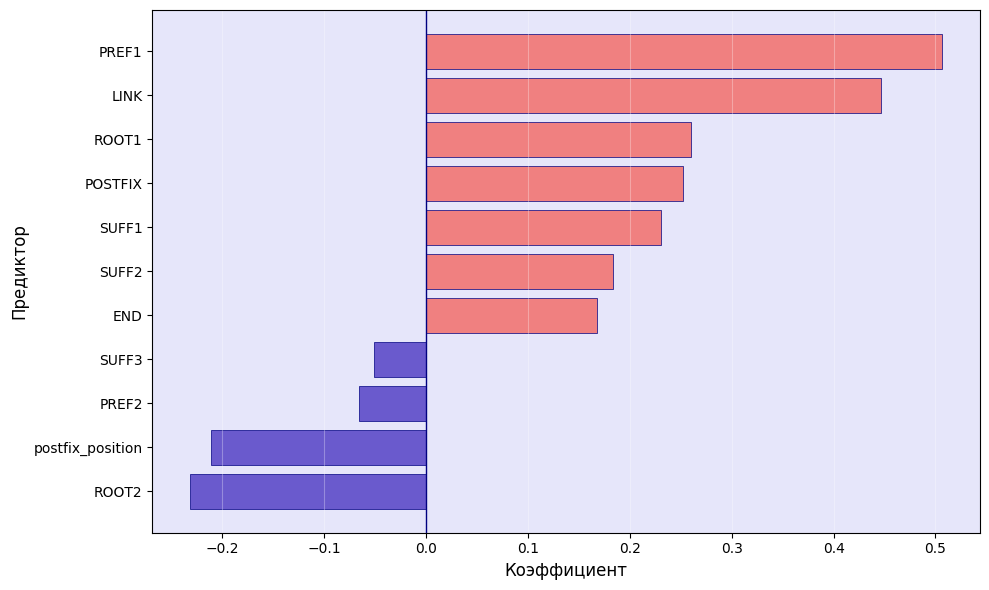

In [236]:
coef = [reg.coef_[0][0]] + list(reg.coef_[0][2:])
coef_df = pd.DataFrame({
    'Морфема': morpheme_cols,
    'Коэффициент': coef
}).sort_values('Коэффициент', ascending=True)

# Цвета: slateblue для отрицательных, lightcoral для положительных
colors = ['slateblue' if c < 0 else 'lightcoral' for c in coef_df['Коэффициент']]

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_facecolor('lavender')
ax.barh(coef_df['Морфема'], coef_df['Коэффициент'], color=colors, edgecolor='navy', lw=0.5)
ax.axvline(x=0, color='navy', lw=1)
ax.set_xlabel('Коэффициент', fontsize=12)
ax.set_ylabel('Предиктор', fontsize=12)
ax.grid(True, alpha=0.3, color='white', axis='x')
plt.tight_layout()
plt.show()

## Все языки part norm

In [241]:
if 'pair' in df.columns:
    df1 = df_all1_n.drop('pair', axis=1)
    
# предсказываем, ухудшилось ли угадывание при наличии параллельного тектста (1), или улучшилось / осталось прежним (0) 
df1['binary'] = (df1['explained_mistakes'] < 0).astype(int)
    
x = df1.loc[:, :'POSTFIX']
y = df1['binary']
    
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, stratify=y, random_state=42
)    
    
train_indices = x_train.index
test_indices = x_test.index

X_train_np = x_train.to_numpy()
y_train_np = y_train.to_numpy()
X_test_np = x_test.to_numpy()
y_test_np = y_test.to_numpy()

scaler = StandardScaler()
x_train_np = scaler.fit_transform(X_train_np)
x_test_np = scaler.transform(X_test_np)
    
reg = LogisticRegression(max_iter=1000)
    
cv_results = cross_validate(reg, x_train_np, y_train_np, cv=5, scoring='f1_macro')
cv_output = pd.DataFrame(cv_results).sort_values(['test_score'], ascending=False)

reg.fit(x_train_np, y_train_np)
    
y_pred = reg.predict(x_test_np)
y_pred_proba = reg.predict_proba(x_test_np)[:, 1]
    
dff_all1_n = df_all1_n.copy()
dff_all1_n = dff_all1_n.drop(test_indices)

df_all1_n.loc[test_indices, 'pred_class'] = y_pred
df_all1_n.loc[test_indices, 'pred_proba'] = y_pred_proba

df_all1_n = df_all1_n.drop(train_indices)
df_all1_n['correctness'] = df_all1_n.apply(check_row, axis=1)

cv_output

,fit_time,score_time,test_score
4,0.001416,0.001605,0.613333
0,0.002724,0.002580,0.602868
3,0.001657,0.001693,0.581731
1,0.003948,0.002601,0.558180
2,0.001780,0.001891,0.517241


In [242]:
print(classification_report(y_test_np, y_pred))

              precision    recall  f1-score   support

           0       0.57      0.72      0.63        36
           1       0.64      0.47      0.55        38

    accuracy                           0.59        74
   macro avg       0.60      0.60      0.59        74
weighted avg       0.61      0.59      0.59        74



In [243]:
mean_absolute_error(y_test, y_pred_proba), r2_score(y_test, y_pred_proba)

(0.47457540450874, 0.006844664300889258)

In [244]:
df_all1_n.to_csv(
    'logreg_ana/part_norm/all_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

In [245]:
for col, coef in zip(df_all1_n.columns[1:-3], reg.coef_[0]):
    print(f'{col}: {round(coef, 3)}')

postfix_position: -0.08
different_agreement: 0.031
PREF1: 0.47
PREF2: 0.291
ROOT1: 0.122
ROOT2: 0.0
LINK: -0.013
SUFF1: 0.353
SUFF2: 0.086
SUFF3: -0.015
END: -0.0
POSTFIX: 0.121


In [246]:
morpheme_cols = ['postfix_position', 'different_agreement', 'PREF1', 'PREF2', 'ROOT1', 'ROOT2', 'LINK', 
                 'SUFF1', 'SUFF2', 'SUFF3', 'END', 'POSTFIX']

df_concat = pd.concat([df_all1_n, dff_all1_n], ignore_index=True)
X = df_concat[morpheme_cols].copy()

# UMAP до 2D
reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(X)

# Добавляем координаты и класс
df_viz = df_concat.copy()
df_viz['x_umap'] = embedding[:, 0]
df_viz['y_umap'] = embedding[:, 1]
df_viz['Класс'] = (df_concat['explained_mistakes'] < 0).map({True: 'Ухудшение', False: 'Нет ухудшения'})

# Интерактивный график
fig = px.scatter(df_viz, 
                 x='x_umap',        
                 y='y_umap',        
                 color='Класс',
                 color_discrete_map={'Нет ухудшения': '#6A5ACD', 'Ухудшение': '#F08080'},
                 hover_data=['pair', 'PREF1', 'ROOT1', 'SUFF1'],
                 title='Разделение классов по морфемным расстояниям')

fig.update_layout(
    plot_bgcolor='lavender',
    paper_bgcolor='white'
)
fig.show()

## Все языки all norm

In [251]:
if 'pair' in df.columns:
    df1 = df_all2_n.drop('pair', axis=1)
    
# предсказываем, ухудшилось ли угадывание при наличии параллельного тектста (1), или улучшилось / осталось прежним (0) 
df1['binary'] = (df1['explained_mistakes'] < 0).astype(int)
    
x = df1.loc[:, :'POSTFIX']
y = df1['binary']
    
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, stratify=y, random_state=42
)    
    
train_indices = x_train.index
test_indices = x_test.index

X_train_np = x_train.to_numpy()
y_train_np = y_train.to_numpy()
X_test_np = x_test.to_numpy()
y_test_np = y_test.to_numpy()

scaler = StandardScaler()
x_train_np = scaler.fit_transform(X_train_np)
x_test_np = scaler.transform(X_test_np)
    
reg = LogisticRegression(max_iter=1000)
    
cv_results = cross_validate(reg, x_train_np, y_train_np, cv=5, scoring='f1_macro')
cv_output = pd.DataFrame(cv_results).sort_values(['test_score'], ascending=False)

reg.fit(x_train_np, y_train_np)
    
y_pred = reg.predict(x_test_np)
y_pred_proba = reg.predict_proba(x_test_np)[:, 1]
    
dff_all2_n = df_all2_n.copy()
dff_all2_n = dff_all2_n.drop(test_indices)

df_all2_n.loc[test_indices, 'pred_class'] = y_pred
df_all2_n.loc[test_indices, 'pred_proba'] = y_pred_proba

df_all2_n = df_all2_n.drop(train_indices)
df_all2_n['correctness'] = df_all2_n.apply(check_row, axis=1)

cv_output

,fit_time,score_time,test_score
3,0.003068,0.002450,0.608654
1,0.002668,0.003005,0.605932
0,0.002445,0.002322,0.601367
2,0.013835,0.002933,0.596804
4,0.002966,0.003184,0.586335


In [252]:
print(classification_report(y_test_np, y_pred))

              precision    recall  f1-score   support

           0       0.64      0.86      0.73       128
           1       0.70      0.41      0.52       105

    accuracy                           0.66       233
   macro avg       0.67      0.63      0.63       233
weighted avg       0.67      0.66      0.64       233



In [253]:
mean_absolute_error(y_test, y_pred_proba), r2_score(y_test, y_pred_proba)

(0.44731309797745233, 0.11407271343793712)

In [254]:
df_all2_n.to_csv(
    'logreg_ana/both_norm/all_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

In [255]:
for col, coef in zip(df_all2_n.columns[1:-3], reg.coef_[0]):
    print(f'{col}: {round(coef, 3)}')

postfix_position: -0.214
different_agreement: 0.054
PREF1: 0.477
PREF2: 0.158
ROOT1: 0.185
ROOT2: -0.101
LINK: 0.258
SUFF1: 0.205
SUFF2: 0.146
SUFF3: -0.125
END: 0.118
POSTFIX: 0.144


In [256]:
morpheme_cols = ['postfix_position', 'different_agreement', 'PREF1', 'PREF2', 'ROOT1', 'ROOT2', 'LINK', 
                 'SUFF1', 'SUFF2', 'SUFF3', 'END', 'POSTFIX']

df_concat = pd.concat([df_all2_n, dff_all2_n], ignore_index=True)
X = df_concat[morpheme_cols].copy()

# UMAP до 2D
reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(X)

# Добавляем координаты и класс
df_viz = df_concat.copy()
df_viz['x_umap'] = embedding[:, 0]
df_viz['y_umap'] = embedding[:, 1]
df_viz['Класс'] = (df_concat['explained_mistakes'] < 0).map({True: 'Ухудшение', False: 'Нет ухудшения'})

# Интерактивный график
fig = px.scatter(df_viz, 
                 x='x_umap',        
                 y='y_umap',        
                 color='Класс',
                 color_discrete_map={'Нет ухудшения': '#6A5ACD', 'Ухудшение': '#F08080'},
                 hover_data=['pair', 'postfix_position', 'different_agreement', 'PREF1', 'PREF2', 'ROOT1', 'ROOT2', 'LINK', 
                 'SUFF1', 'SUFF2', 'SUFF3', 'END', 'POSTFIX'],
                 title='Разделение классов по морфемным расстояниям')

fig.update_layout(
    plot_bgcolor='lavender',
    paper_bgcolor='white'
)
fig.show()

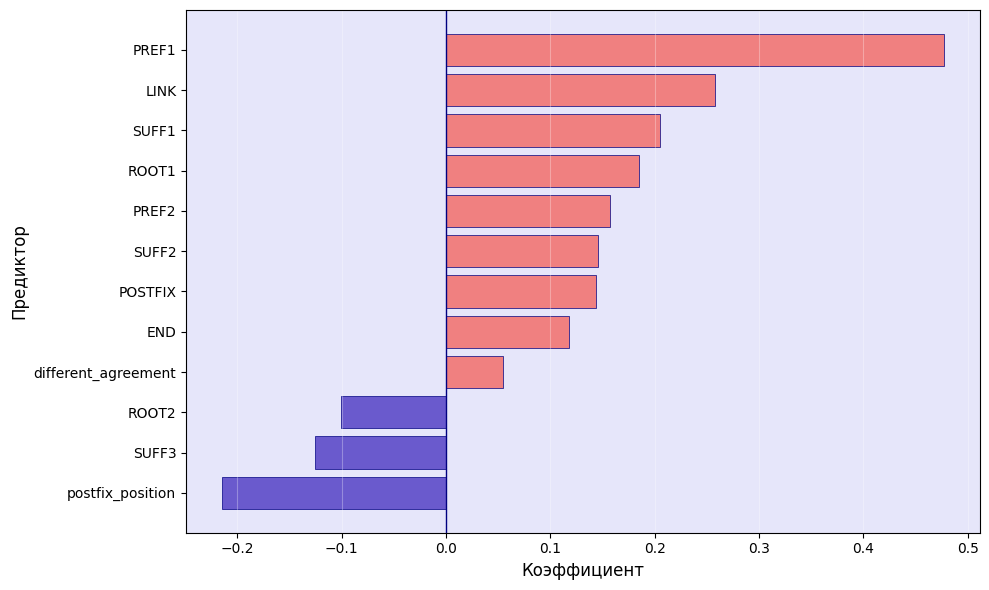

In [257]:
coef_df = pd.DataFrame({
    'Морфема': morpheme_cols,
    'Коэффициент': reg.coef_[0]
}).sort_values('Коэффициент', ascending=True)

# Цвета: slateblue для отрицательных, lightcoral для положительных
colors = ['slateblue' if c < 0 else 'lightcoral' for c in coef_df['Коэффициент']]

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_facecolor('lavender')
ax.barh(coef_df['Морфема'], coef_df['Коэффициент'], color=colors, edgecolor='navy', lw=0.5)
ax.axvline(x=0, color='navy', lw=1)
ax.set_xlabel('Коэффициент', fontsize=12)
ax.set_ylabel('Предиктор', fontsize=12)
ax.grid(True, alpha=0.3, color='white', axis='x')
plt.tight_layout()
plt.show()

In [258]:
if 'pair' in df.columns:
    df1 = df_all_langs.drop('pair', axis=1)
    
# предсказываем, ухудшилось ли угадывание при наличии параллельного тектста (1), или улучшилось / осталось прежним (0) 
df1['binary'] = (df1['explained_mistakes'] < 0).astype(int)
    
x = df1.loc[:, :'POSTFIX']
y = df1['binary']
    
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, stratify=y, random_state=42
)    
    
train_indices = x_train.index
test_indices = x_test.index

X_train_np = x_train.to_numpy()
y_train_np = y_train.to_numpy()
X_test_np = x_test.to_numpy()
y_test_np = y_test.to_numpy()

scaler = StandardScaler()
x_train_np = scaler.fit_transform(X_train_np)
x_test_np = scaler.transform(X_test_np)
    
reg = LogisticRegression(max_iter=1000)
    
cv_results = cross_validate(reg, x_train_np, y_train_np, cv=5, scoring='f1_macro')
cv_output = pd.DataFrame(cv_results).sort_values(['test_score'], ascending=False)

reg.fit(x_train_np, y_train_np)
    
y_pred = reg.predict(x_test_np)
y_pred_proba = reg.predict_proba(x_test_np)[:, 1]
    
df_all_langs.loc[test_indices, 'pred_class'] = y_pred
df_all_langs.loc[test_indices, 'pred_proba'] = y_pred_proba

df_all_langs = df_all_langs.drop(train_indices)
df_all_langs['correctness'] = df_all_langs.apply(check_row, axis=1)

cv_output

,fit_time,score_time,test_score
1,0.004995,0.003396,0.634858
2,0.003542,0.002200,0.613234
3,0.010477,0.002233,0.605707
4,0.002414,0.002063,0.543648
0,0.010732,0.004695,0.527223


In [259]:
print(classification_report(y_test_np, y_pred))

              precision    recall  f1-score   support

           0       0.66      0.80      0.73        91
           1       0.63      0.46      0.53        68

    accuracy                           0.65       159
   macro avg       0.65      0.63      0.63       159
weighted avg       0.65      0.65      0.64       159



In [260]:
df_all_langs.to_csv(
    'logreg_ana/true/all_langs_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

In [261]:
for col, coef in zip(df_all_langs.columns[1:-3], reg.coef_[0]):
    print(f'{col}: {round(coef, 3)}')

ukr: -0.243
bel: -0.003
bg: 0.008
sb: 0.071
pol: 0.043
cz: -0.01
sk: 0.051
sn: 0.121
postfix_position: -0.219
different_agreement: 0.0
PREF1: 0.52
PREF2: -0.103
ROOT1: 0.144
ROOT2: -0.21
LINK: 0.43
SUFF1: 0.147
SUFF2: 0.188
SUFF3: -0.093
END: 0.174
POSTFIX: 0.23


## Все языки true norm + 1.0 на язык

In [262]:
if 'pair' in df.columns:
    df1 = df_all_langs_n.drop('pair', axis=1)
    
# предсказываем, ухудшилось ли угадывание при наличии параллельного тектста (1), или улучшилось / осталось прежним (0) 
df1['binary'] = (df1['explained_mistakes'] < 0).astype(int)
    
x = df1.loc[:, :'POSTFIX']
y = df1['binary']
    
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, stratify=y, random_state=42
)    
    
train_indices = x_train.index
test_indices = x_test.index

X_train_np = x_train.to_numpy()
y_train_np = y_train.to_numpy()
X_test_np = x_test.to_numpy()
y_test_np = y_test.to_numpy()

scaler = StandardScaler()
x_train_np = scaler.fit_transform(X_train_np)
x_test_np = scaler.transform(X_test_np)
    
reg = LogisticRegression(max_iter=1000)
    
cv_results = cross_validate(reg, x_train_np, y_train_np, cv=5, scoring='f1_macro')
cv_output = pd.DataFrame(cv_results).sort_values(['test_score'], ascending=False)

reg.fit(x_train_np, y_train_np)
    
y_pred = reg.predict(x_test_np)
y_pred_proba = reg.predict_proba(x_test_np)[:, 1]
    
dff_all_langs_n = df_all_langs_n.copy()
dff_all_langs_n = dff_all_langs_n.drop(test_indices)

df_all_langs_n.loc[test_indices, 'pred_class'] = y_pred
df_all_langs_n.loc[test_indices, 'pred_proba'] = y_pred_proba

df_all_langs_n = df_all_langs_n.drop(train_indices)
df_all_langs_n['correctness'] = df_all_langs_n.apply(check_row, axis=1)

cv_output

,fit_time,score_time,test_score
3,0.018389,0.002828,0.626471
1,0.002894,0.002169,0.619840
2,0.002936,0.002942,0.613234
4,0.004091,0.002621,0.593531
0,0.013852,0.002931,0.571620


In [263]:
print(classification_report(y_test_np, y_pred))

              precision    recall  f1-score   support

           0       0.69      0.79      0.73        91
           1       0.65      0.51      0.57        68

    accuracy                           0.67       159
   macro avg       0.67      0.65      0.65       159
weighted avg       0.67      0.67      0.67       159



In [264]:
mean_absolute_error(y_test, y_pred_proba), r2_score(y_test, y_pred_proba)

(0.4183559078753258, 0.1446508439727594)

In [265]:
df_all_langs_n.to_csv(
    'logreg_ana/true_norm/all_langs_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

In [266]:
for col, coef in zip(df_all_langs_n.columns[1:-3], reg.coef_[0]):
    print(f'{col}: {round(coef, 3)}')

ukr: -0.24
bel: -0.013
bg: 0.014
sb: 0.066
pol: 0.031
cz: -0.001
sk: 0.053
sn: 0.129
postfix_position: -0.208
different_agreement: 0.0
PREF1: 0.515
PREF2: -0.084
ROOT1: 0.238
ROOT2: -0.258
LINK: 0.463
SUFF1: 0.206
SUFF2: 0.182
SUFF3: -0.053
END: 0.149
POSTFIX: 0.237


In [267]:
morpheme_cols = ['postfix_position', 'different_agreement', 'PREF1', 'PREF2', 'ROOT1', 'ROOT2', 'LINK', 
                 'SUFF1', 'SUFF2', 'SUFF3', 'END', 'POSTFIX']

df_concat = pd.concat([df_all_langs_n, dff_all_langs_n], ignore_index=True)
X = df_concat[morpheme_cols].copy()

# UMAP до 2D
reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(X)

# Добавляем координаты и класс
df_viz = df_concat.copy()
df_viz['x_umap'] = embedding[:, 0]
df_viz['y_umap'] = embedding[:, 1]
df_viz['Класс'] = (df_concat['explained_mistakes'] < 0).map({True: 'Ухудшение', False: 'Нет ухудшения'})

# Интерактивный график
fig = px.scatter(df_viz, 
                 x='x_umap',        
                 y='y_umap',        
                 color='Класс',
                 color_discrete_map={'Нет ухудшения': '#6A5ACD', 'Ухудшение': '#F08080'},
                 hover_data=['pair', 'PREF1', 'ROOT1', 'SUFF1'],
                 title='Разделение классов по морфемным расстояниям')

fig.update_layout(
    plot_bgcolor='lavender',
    paper_bgcolor='white'
)
fig.show()

In [268]:
if 'pair' in df.columns:
    df1 = df_all_langs1.drop('pair', axis=1)
    
# предсказываем, ухудшилось ли угадывание при наличии параллельного тектста (1), или улучшилось / осталось прежним (0) 
df1['binary'] = (df1['explained_mistakes'] < 0).astype(int)
    
x = df1.loc[:, :'POSTFIX']
y = df1['binary']
    
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, stratify=y, random_state=42
)    
    
train_indices = x_train.index
test_indices = x_test.index

X_train_np = x_train.to_numpy()
y_train_np = y_train.to_numpy()
X_test_np = x_test.to_numpy()
y_test_np = y_test.to_numpy()

scaler = StandardScaler()
x_train_np = scaler.fit_transform(X_train_np)
x_test_np = scaler.transform(X_test_np)
    
reg = LogisticRegression(max_iter=1000)
    
cv_results = cross_validate(reg, x_train_np, y_train_np, cv=5, scoring='f1_macro')
cv_output = pd.DataFrame(cv_results).sort_values(['test_score'], ascending=False)

reg.fit(x_train_np, y_train_np)
    
y_pred = reg.predict(x_test_np)
y_pred_proba = reg.predict_proba(x_test_np)[:, 1]
    
df_all_langs1.loc[test_indices, 'pred_class'] = y_pred
df_all_langs1.loc[test_indices, 'pred_proba'] = y_pred_proba

df_all_langs1 = df_all_langs1.drop(train_indices)
df_all_langs1['correctness'] = df_all_langs1.apply(check_row, axis=1)

cv_output

,fit_time,score_time,test_score
0,0.006160,0.005164,0.656177
2,0.001393,0.002049,0.620690
4,0.002723,0.002545,0.616587
1,0.004252,0.001606,0.590278
3,0.005744,0.002934,0.533234


In [269]:
print(classification_report(y_test_np, y_pred))

              precision    recall  f1-score   support

           0       0.62      0.69      0.66        36
           1       0.68      0.61      0.64        38

    accuracy                           0.65        74
   macro avg       0.65      0.65      0.65        74
weighted avg       0.65      0.65      0.65        74



In [270]:
df_all_langs1.to_csv(
    'logreg_ana/part/all_langs_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

In [271]:
for col, coef in zip(df_all_langs1.columns[1:-3], reg.coef_[0]):
    print(f'{col}: {round(coef, 3)}')

ukr: -0.146
bel: -0.008
bg: 0.003
sb: -0.025
pol: -0.037
cz: 0.275
sk: -0.035
sn: -0.034
postfix_position: -0.069
different_agreement: 0.003
PREF1: 0.373
PREF2: 0.234
ROOT1: 0.069
ROOT2: 0.0
LINK: -0.067
SUFF1: 0.411
SUFF2: 0.066
SUFF3: -0.01
END: -0.096
POSTFIX: 0.073


## Все языки part norm + 1.0 на язык

In [272]:
if 'pair' in df.columns:
    df1 = df_all_langs1_n.drop('pair', axis=1)
    
# предсказываем, ухудшилось ли угадывание при наличии параллельного тектста (1), или улучшилось / осталось прежним (0) 
df1['binary'] = (df1['explained_mistakes'] < 0).astype(int)
    
x = df1.loc[:, :'POSTFIX']
y = df1['binary']
    
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, stratify=y, random_state=42
)    
    
train_indices = x_train.index
test_indices = x_test.index

X_train_np = x_train.to_numpy()
y_train_np = y_train.to_numpy()
X_test_np = x_test.to_numpy()
y_test_np = y_test.to_numpy()

scaler = StandardScaler()
x_train_np = scaler.fit_transform(X_train_np)
x_test_np = scaler.transform(X_test_np)
    
reg = LogisticRegression(max_iter=1000)
    
cv_results = cross_validate(reg, x_train_np, y_train_np, cv=5, scoring='f1_macro')
cv_output = pd.DataFrame(cv_results).sort_values(['test_score'], ascending=False)

reg.fit(x_train_np, y_train_np)
    
y_pred = reg.predict(x_test_np)
y_pred_proba = reg.predict_proba(x_test_np)[:, 1]
    
dff_all_langs1_n = df_all_langs1_n.copy()
dff_all_langs1_n = dff_all_langs1_n.drop(test_indices)

df_all_langs1_n.loc[test_indices, 'pred_class'] = y_pred
df_all_langs1_n.loc[test_indices, 'pred_proba'] = y_pred_proba

df_all_langs1_n = df_all_langs1_n.drop(train_indices)
df_all_langs1_n['correctness'] = df_all_langs1_n.apply(check_row, axis=1)

cv_output

,fit_time,score_time,test_score
0,0.002052,0.002898,0.624421
4,0.002722,0.002514,0.618877
2,0.004117,0.004106,0.603330
1,0.007291,0.004232,0.590278
3,0.002040,0.002634,0.533234


In [273]:
print(classification_report(y_test_np, y_pred))

              precision    recall  f1-score   support

           0       0.62      0.69      0.66        36
           1       0.68      0.61      0.64        38

    accuracy                           0.65        74
   macro avg       0.65      0.65      0.65        74
weighted avg       0.65      0.65      0.65        74



In [274]:
mean_absolute_error(y_test, y_pred_proba), r2_score(y_test, y_pred_proba)

(0.4612012054319349, 0.04664200878302416)

In [275]:
df_all_langs1_n.to_csv(
    'logreg_ana/part_norm/all_langs_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

In [276]:
for col, coef in zip(df_all_langs1_n.columns[1:-3], reg.coef_[0]):
    print(f'{col}: {round(coef, 3)}')

ukr: -0.13
bel: -0.001
bg: -0.01
sb: -0.052
pol: -0.024
cz: 0.281
sk: -0.032
sn: -0.037
postfix_position: -0.077
different_agreement: 0.035
PREF1: 0.458
PREF2: 0.277
ROOT1: 0.11
ROOT2: 0.0
LINK: 0.011
SUFF1: 0.388
SUFF2: 0.124
SUFF3: -0.015
END: 0.0
POSTFIX: 0.123


In [277]:
morpheme_cols = ['postfix_position', 'different_agreement', 'PREF1', 'PREF2', 'ROOT1', 'ROOT2', 'LINK', 
                 'SUFF1', 'SUFF2', 'SUFF3', 'END', 'POSTFIX']

df_concat = pd.concat([df_all_langs1_n, dff_all_langs1_n], ignore_index=True)
X = df_concat[morpheme_cols].copy()

# UMAP до 2D
reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(X)

# Добавляем координаты и класс
df_viz = df_concat.copy()
df_viz['x_umap'] = embedding[:, 0]
df_viz['y_umap'] = embedding[:, 1]
df_viz['Класс'] = (df_concat['explained_mistakes'] < 0).map({True: 'Ухудшение', False: 'Нет ухудшения'})

# Интерактивный график
fig = px.scatter(df_viz, 
                 x='x_umap',        
                 y='y_umap',        
                 color='Класс',
                 color_discrete_map={'Нет ухудшения': '#6A5ACD', 'Ухудшение': '#F08080'},
                 hover_data=['pair', 'PREF1', 'ROOT1', 'SUFF1'],
                 title='Разделение классов по морфемным расстояниям')

fig.update_layout(
    plot_bgcolor='lavender',
    paper_bgcolor='white'
)
fig.show()

In [278]:
if 'pair' in df.columns:
    df1 = df_all_langs2.drop('pair', axis=1)
    
# предсказываем, ухудшилось ли угадывание при наличии параллельного тектста (1), или улучшилось / осталось прежним (0) 
df1['binary'] = (df1['explained_mistakes'] < 0).astype(int)
    
x = df1.loc[:, :'POSTFIX']
y = df1['binary']
    
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, stratify=y, random_state=42
)    
    
train_indices = x_train.index
test_indices = x_test.index

X_train_np = x_train.to_numpy()
y_train_np = y_train.to_numpy()
X_test_np = x_test.to_numpy()
y_test_np = y_test.to_numpy()

scaler = StandardScaler()
x_train_np = scaler.fit_transform(X_train_np)
x_test_np = scaler.transform(X_test_np)
    
reg = LogisticRegression(max_iter=1000)
    
cv_results = cross_validate(reg, x_train_np, y_train_np, cv=5, scoring='f1_macro')
cv_output = pd.DataFrame(cv_results).sort_values(['test_score'], ascending=False)

reg.fit(x_train_np, y_train_np)
    
y_pred = reg.predict(x_test_np)
y_pred_proba = reg.predict_proba(x_test_np)[:, 1]
    
df_all_langs2.loc[test_indices, 'pred_class'] = y_pred
df_all_langs2.loc[test_indices, 'pred_proba'] = y_pred_proba

df_all_langs2 = df_all_langs2.drop(train_indices)
df_all_langs2['correctness'] = df_all_langs2.apply(check_row, axis=1)

cv_output

,fit_time,score_time,test_score
1,0.001610,0.001608,0.658531
0,0.008456,0.001765,0.643062
3,0.002184,0.003582,0.590925
4,0.002217,0.001859,0.590708
2,0.002143,0.002247,0.548862


In [279]:
print(classification_report(y_test_np, y_pred))

              precision    recall  f1-score   support

           0       0.61      0.81      0.70       128
           1       0.62      0.37      0.46       105

    accuracy                           0.61       233
   macro avg       0.62      0.59      0.58       233
weighted avg       0.62      0.61      0.59       233



In [280]:
df_all_langs2.to_csv(
    'logreg_ana/both/all_langs_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

In [281]:
for col, coef in zip(df_all_langs2.columns[1:-3], reg.coef_[0]):
    print(f'{col}: {round(coef, 3)}')

ukr: -0.221
bel: -0.014
bg: -0.002
sb: -0.044
pol: 0.037
cz: 0.183
sk: 0.101
sn: -0.005
postfix_position: -0.243
different_agreement: 0.06
PREF1: 0.468
PREF2: 0.133
ROOT1: 0.117
ROOT2: -0.06
LINK: 0.207
SUFF1: 0.187
SUFF2: 0.123
SUFF3: -0.126
END: 0.099
POSTFIX: 0.109


## Все языки all norm + 1.0 на язык

In [282]:
if 'pair' in df.columns:
    df1 = df_all_langs2_n.drop('pair', axis=1)
    
# предсказываем, ухудшилось ли угадывание при наличии параллельного тектста (1), или улучшилось / осталось прежним (0) 
df1['binary'] = (df1['explained_mistakes'] < 0).astype(int)
    
x = df1.loc[:, :'POSTFIX']
y = df1['binary']
    
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, stratify=y, random_state=42
)    
    
train_indices = x_train.index
test_indices = x_test.index

X_train_np = x_train.to_numpy()
y_train_np = y_train.to_numpy()
X_test_np = x_test.to_numpy()
y_test_np = y_test.to_numpy()

scaler = StandardScaler()
x_train_np = scaler.fit_transform(X_train_np)
x_test_np = scaler.transform(X_test_np)
    
reg = LogisticRegression(max_iter=1000)
    
cv_results = cross_validate(reg, x_train_np, y_train_np, cv=5, scoring='f1_macro')
cv_output = pd.DataFrame(cv_results).sort_values(['test_score'], ascending=False)

reg.fit(x_train_np, y_train_np)
    
y_pred = reg.predict(x_test_np)
y_pred_proba = reg.predict_proba(x_test_np)[:, 1]
    
dff_all_langs2_n = df_all_langs2_n.copy()
dff_all_langs2_n = dff_all_langs2_n.drop(test_indices)

df_all_langs2_n.loc[test_indices, 'pred_class'] = y_pred
df_all_langs2_n.loc[test_indices, 'pred_proba'] = y_pred_proba

df_all_langs2_n = df_all_langs2_n.drop(train_indices)
df_all_langs2_n['correctness'] = df_all_langs2_n.apply(check_row, axis=1)

cv_output

,fit_time,score_time,test_score
1,0.002035,0.004102,0.643992
0,0.002636,0.002667,0.642884
3,0.001639,0.001921,0.608736
2,0.005172,0.001693,0.587483
4,0.002291,0.001841,0.567403


In [283]:
print(classification_report(y_test_np, y_pred))

              precision    recall  f1-score   support

           0       0.62      0.80      0.70       128
           1       0.63      0.41      0.50       105

    accuracy                           0.63       233
   macro avg       0.63      0.61      0.60       233
weighted avg       0.63      0.63      0.61       233



In [284]:
mean_absolute_error(y_test, y_pred_proba), r2_score(y_test, y_pred_proba)

(0.4466366184306256, 0.08743875869644524)

In [285]:
df_all_langs2_n.to_csv(
    'logreg_ana/both_norm/all_langs_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

In [286]:
for col, coef in zip(df_all_langs2_n.columns[1:-3], reg.coef_[0]):
    print(f'{col}: {round(coef, 3)}')

ukr: -0.218
bel: -0.021
bg: 0.001
sb: -0.06
pol: 0.042
cz: 0.188
sk: 0.101
sn: 0.003
postfix_position: -0.232
different_agreement: 0.061
PREF1: 0.471
PREF2: 0.163
ROOT1: 0.184
ROOT2: -0.122
LINK: 0.28
SUFF1: 0.197
SUFF2: 0.158
SUFF3: -0.11
END: 0.104
POSTFIX: 0.13


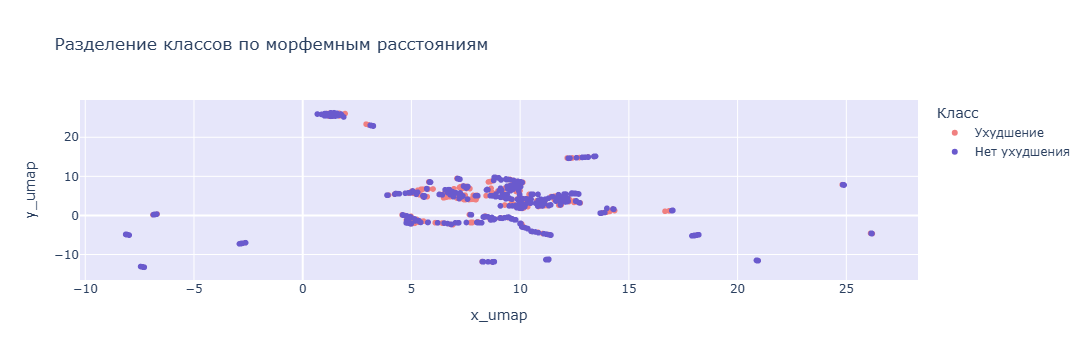

In [287]:
morpheme_cols = ['postfix_position', 'different_agreement', 'PREF1', 'PREF2', 'ROOT1', 'ROOT2', 'LINK', 
                 'SUFF1', 'SUFF2', 'SUFF3', 'END', 'POSTFIX']

df_concat = pd.concat([df_all_langs2_n, dff_all_langs2_n], ignore_index=True)
X = df_concat[morpheme_cols].copy()

# UMAP до 2D
reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(X)

# Добавляем координаты и класс
df_viz = df_concat.copy()
df_viz['x_umap'] = embedding[:, 0]
df_viz['y_umap'] = embedding[:, 1]
df_viz['Класс'] = (df_concat['explained_mistakes'] < 0).map({True: 'Ухудшение', False: 'Нет ухудшения'})

# Интерактивный график
fig = px.scatter(df_viz, 
                 x='x_umap',        
                 y='y_umap',        
                 color='Класс',
                 color_discrete_map={'Нет ухудшения': '#6A5ACD', 'Ухудшение': '#F08080'},
                 hover_data=['pair', 'PREF1', 'ROOT1', 'SUFF1'],
                 title='Разделение классов по морфемным расстояниям')

fig.update_layout(
    plot_bgcolor='lavender',
    paper_bgcolor='white'
)
fig.show()